## Importación de librerías

In [541]:
# Importación de librerías
# -----------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

## Carga de datos

In [542]:
df = pd.read_csv(r"C:\Users\pchic\Downloads\dataset_estudiantes (2).csv")
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


## Análisis exploratorio

In [543]:
print(f"El número de filas que tenemos es {df.shape[0]}, y el número de columnas es {df.shape[1]}")

El número de filas que tenemos es 1000, y el número de columnas es 11


In [544]:
df.columns

Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nivel_dificultad', 'tiene_tutor',
       'horario_estudio_preferido', 'estilo_aprendizaje', 'nota_final',
       'aprobado'],
      dtype='str')

In [545]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


In [546]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.072366,4.852218,1.0,6.627548,10.000000,13.372452,25.0
nota_anterior,1000.0,69.885456,14.687697,30.0,59.882644,70.000000,80.117356,100.0
tasa_asistencia,1000.0,73.992079,18.195948,20.0,61.510192,75.000000,88.489808,100.0
horas_sueno,850.0,7.007670,1.444790,4.0,5.995341,7.020701,8.018834,10.0
edad,1000.0,23.532000,3.476933,18.0,21.000000,24.000000,27.000000,29.0
nota_final,1000.0,71.441400,9.562078,30.0,64.775000,71.400000,77.900000,100.0
aprobado,1000.0,0.898000,0.302800,0.0,1.000000,1.000000,1.000000,1.0


Columnas del dataset
horas_estudio_semanal: Número de horas de estudio a la semana.
nota_anterior: Nota que obtuvo el alumno en la convocatoria anterior.
tasa_asistencia: Tasa de asistencia a clase en porcentaje.
horas_sueno: Promedio de horas que duerme el alumno al día.
edad: Edad del alumno.
nivel_dificultad: Dificultad del alumno para el estudio.
tiene_tutor: Indica si el alumno tiene tutor o no.
horario_estudio_preferido: Horario de estudio preferido por el alumno.
estilo_aprendizaje: Forma de estudio que emplea el alumno.
Variables objetivo:
Para regresión: nota_final (variable continua entre 0 y 100)
Para clasificación: aprobado (variable binaria: 1 si la nota es ≥ 60, 0 en caso contrario)

In [547]:
# Comprobamos si existen filas completamente duplicadas
df.duplicated().sum()

np.int64(0)

In [548]:
# Visualizamos las filas duplicadas
df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado


## Identificación de nulos

In [549]:
df.isna().sum()

horas_estudio_semanal          0
nota_anterior                  0
tasa_asistencia                0
horas_sueno                  150
edad                           0
nivel_dificultad               0
tiene_tutor                    0
horario_estudio_preferido    100
estilo_aprendizaje            50
nota_final                     0
aprobado                       0
dtype: int64

### Identificar variables numéricas y categóricas

In [550]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Variables numéricas:\n\n", num_cols)
print("\nVariables categóricas:\n\n", cat_cols)

Variables numéricas:

 Index(['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia',
       'horas_sueno', 'edad', 'nota_final', 'aprobado'],
      dtype='str')

Variables categóricas:

 Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje'],
      dtype='str')


C:\Users\pchic\AppData\Local\Temp\ipykernel_13860\344524921.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


## Variables numéricas

### Estadísticas descriptivas

In [551]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


### Visualizaciones

### Graficar histogramas para variables numéricas

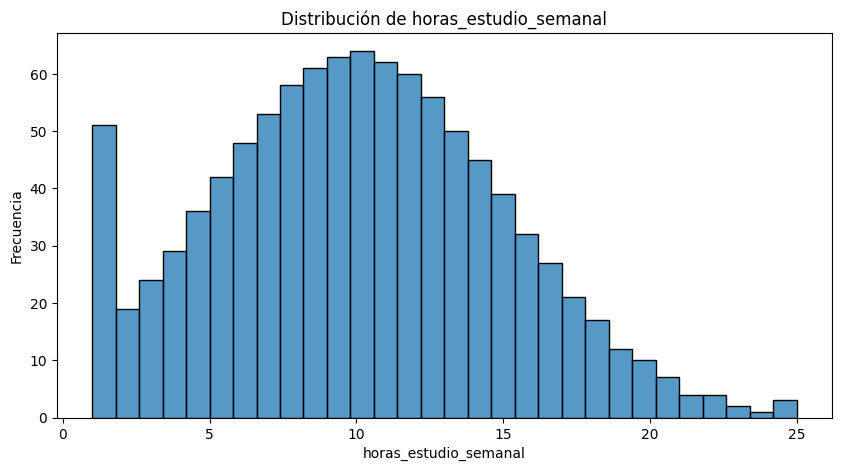

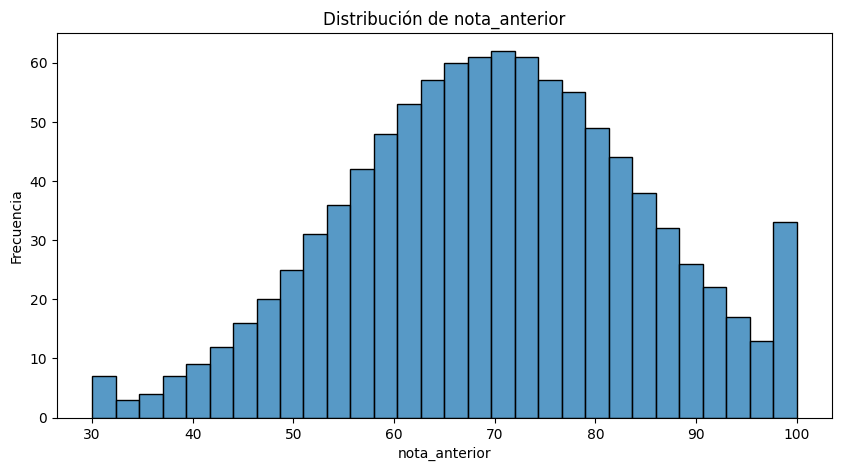

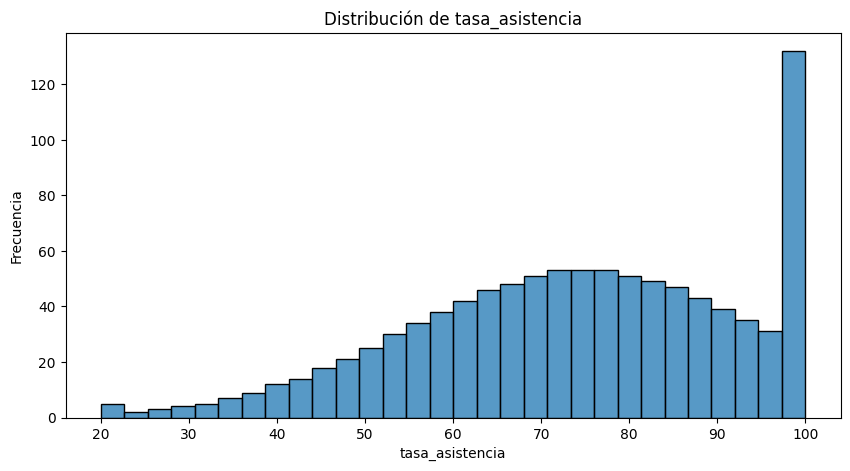

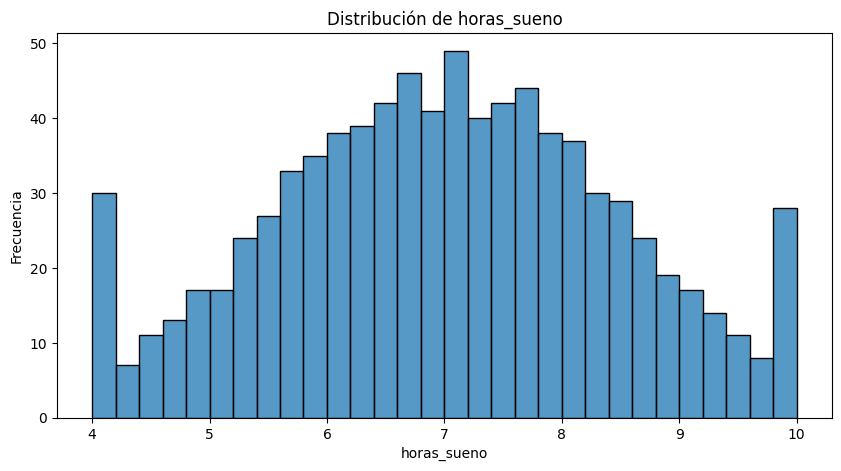

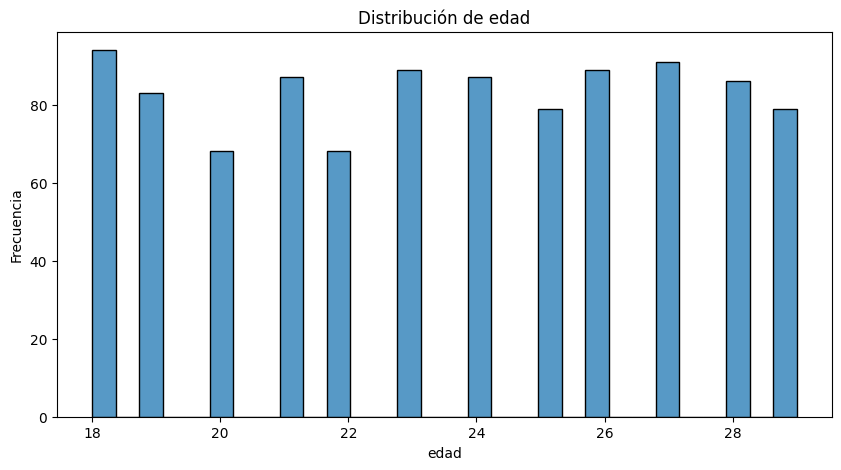

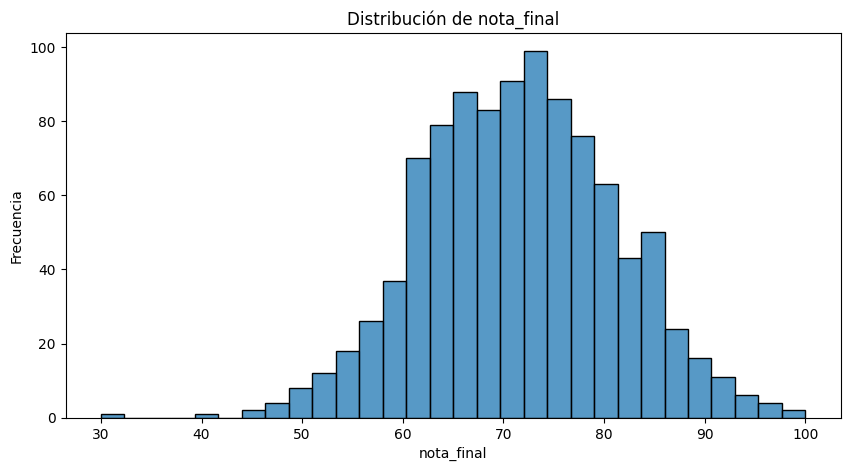

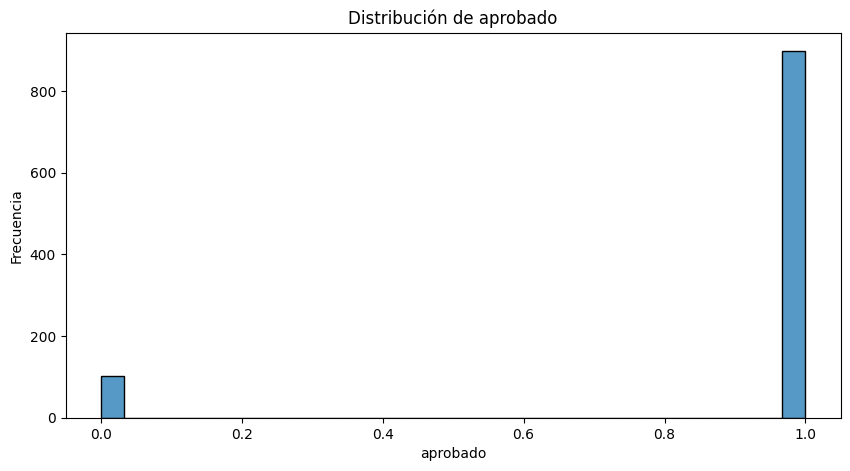

In [552]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=30, edgecolor='black')

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.show()

## Variables categóricas

### Estadísticas descriptivas

In [553]:
df.describe(include = "object").T

C:\Users\pchic\AppData\Local\Temp\ipykernel_13860\726139619.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object").T


,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


### Valores únicos y frecuencias

In [554]:
for col in cat_cols:
    print(f" \n----------- ESTAMOS ANALIZANDO LA COLUMNA: '{col}' -----------\n")
    print(f"Valores únicos: {df[col].unique()}\n")
    print("Frecuencias de los valores únicos de las categorías:")
    display(df[col].value_counts())

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'nivel_dificultad' -----------

Valores únicos: <StringArray>
['Fácil', 'Difícil', 'Medio']
Length: 3, dtype: str

Frecuencias de los valores únicos de las categorías:


nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'tiene_tutor' -----------

Valores únicos: <StringArray>
['Sí', 'No']
Length: 2, dtype: str

Frecuencias de los valores únicos de las categorías:


tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'horario_estudio_preferido' -----------

Valores únicos: <StringArray>
['Tarde', 'Mañana', nan, 'Noche']
Length: 4, dtype: str

Frecuencias de los valores únicos de las categorías:


horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

 
----------- ESTAMOS ANALIZANDO LA COLUMNA: 'estilo_aprendizaje' -----------

Valores únicos: <StringArray>
['Lectura/Escritura', nan, 'Visual', 'Auditivo', 'Kinestésico']
Length: 5, dtype: str

Frecuencias de los valores únicos de las categorías:


estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

### Visualizaciones

Graficar gráficos de barras para variables categóricas

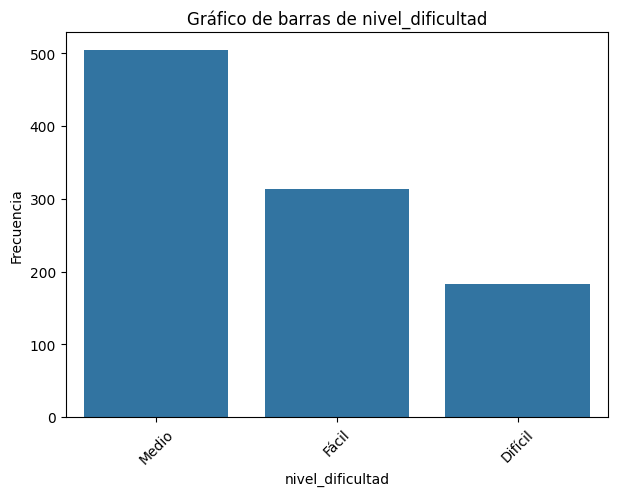

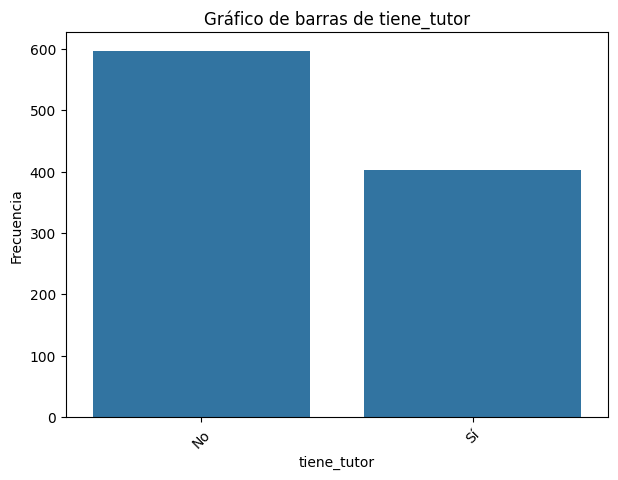

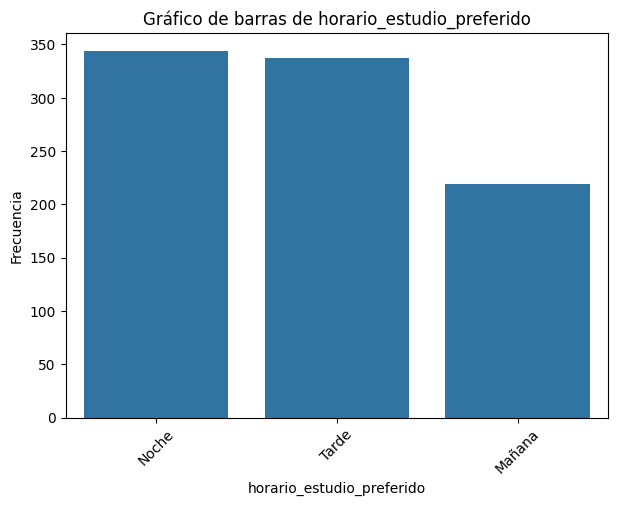

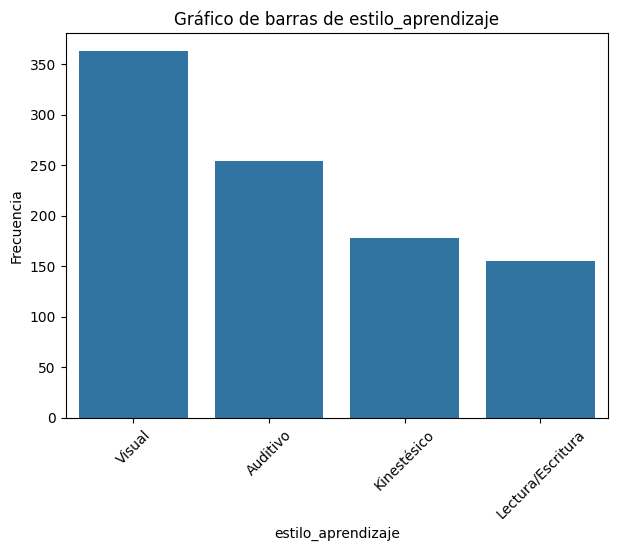

In [555]:
for col in cat_cols:
    num_categories = df[col].nunique()
    width = max(7, min(num_categories * 0.5, 25))
    height = 5  # Altura fija

    plt.figure(figsize=(width, height))
    sns.countplot(x=df[col], order=df[col].value_counts().index)

    plt.title(f'Gráfico de barras de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)

    plt.show()


## Matriz de correlación

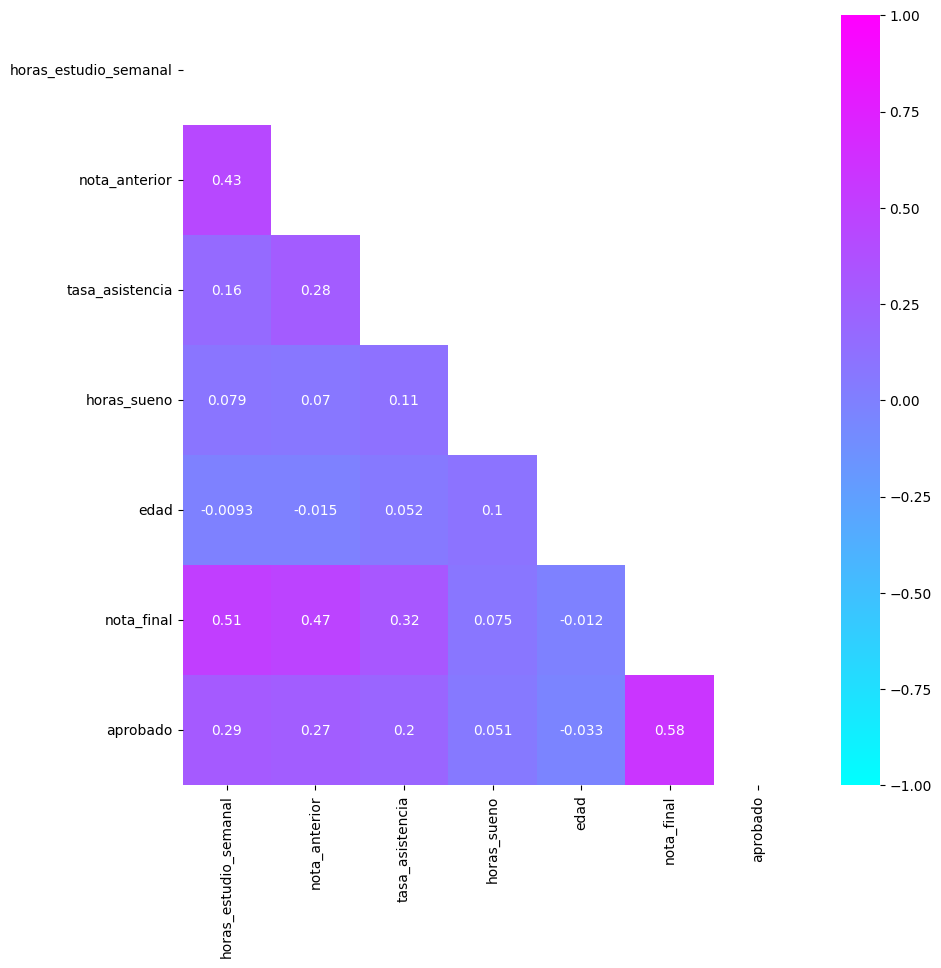

In [556]:
# Calcular la matriz de correlación
corr_matrix = df.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(10, 10))

# Crear una máscara para mostrar solo la parte triangular
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Graficar el mapa de calor
sns.heatmap(corr_matrix, 
            annot=True, 
            vmin=-1, 
            vmax=1, 
            mask=mask,
            cmap='cool')

plt.show()

## Relaciones cruzadas

### Variable objetivo numérica `nota_final`

Generamos gráficos de dispersión

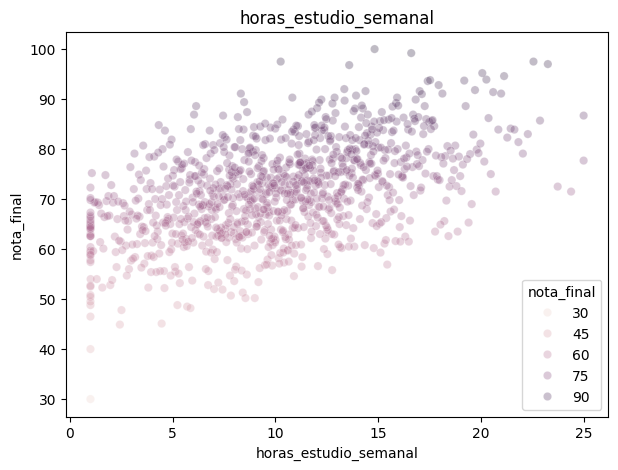

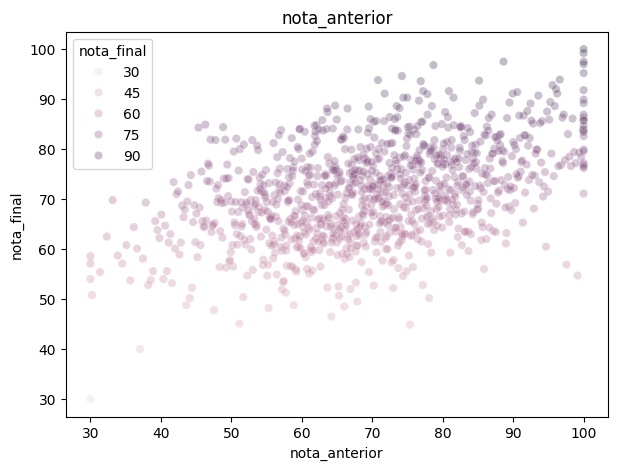

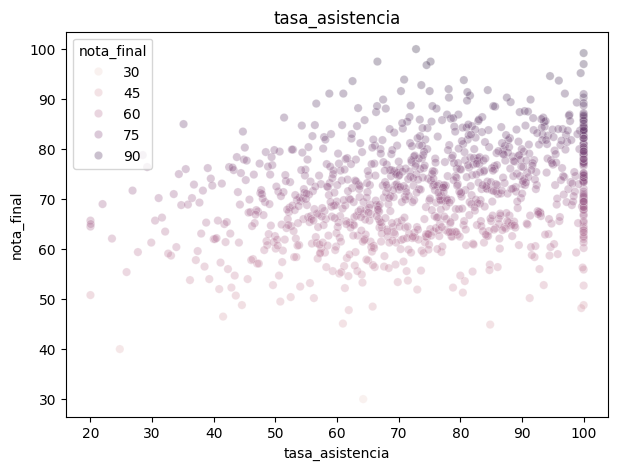

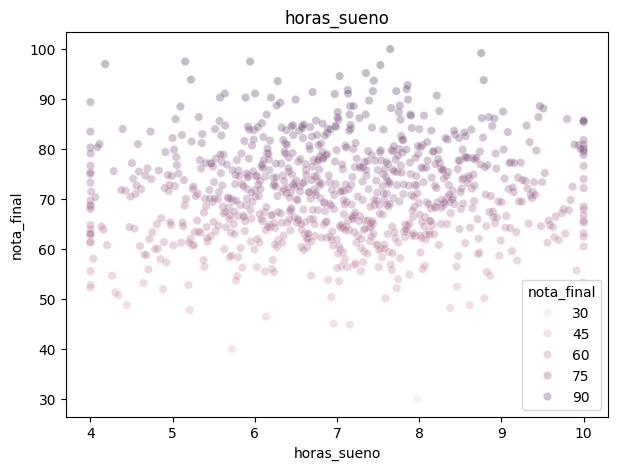

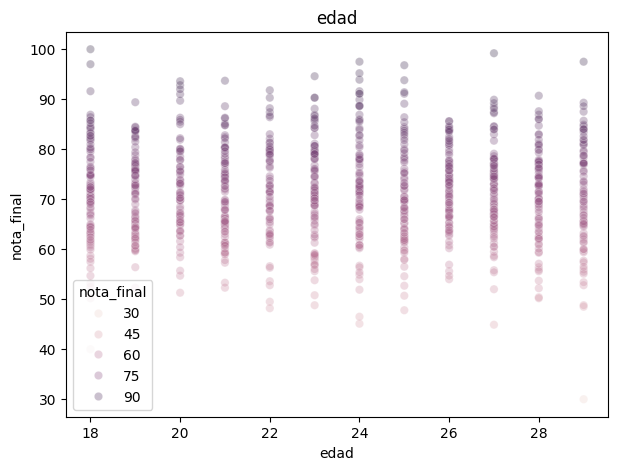

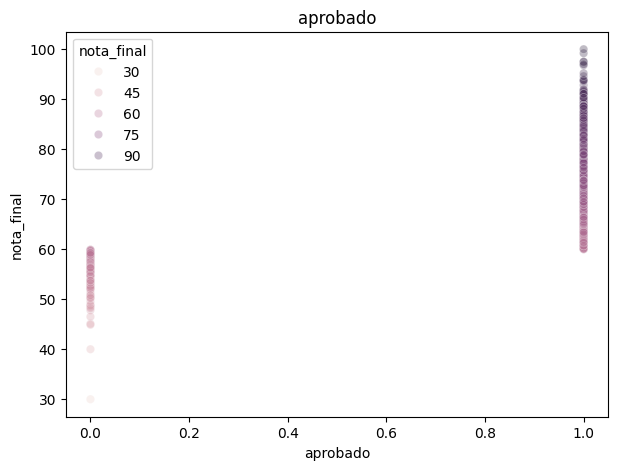

In [557]:
# Definir la variable objetivo
tv = 'nota_final'

# Definir DataFrame y variables numéricas
df_num = df.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num = df_num.columns

# Generar gráficos de dispersión
for col in cols_num:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=df[col], y=df[tv], hue=df['nota_final'], alpha=0.3)
    # sns.scatterplot(x=df[col], y=df[tv])
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.show()


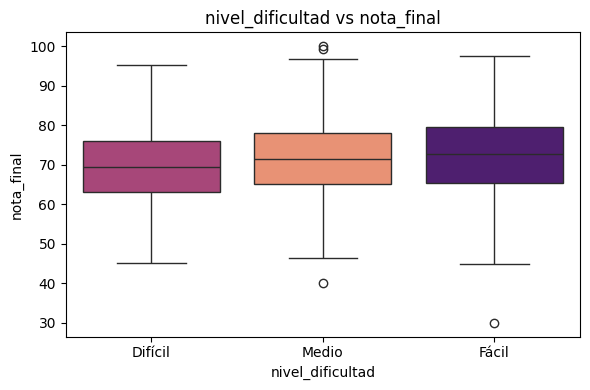

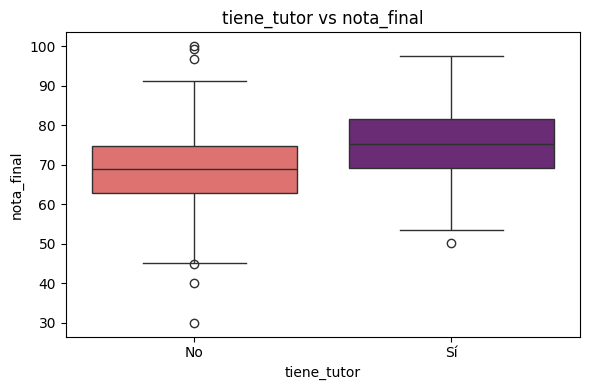

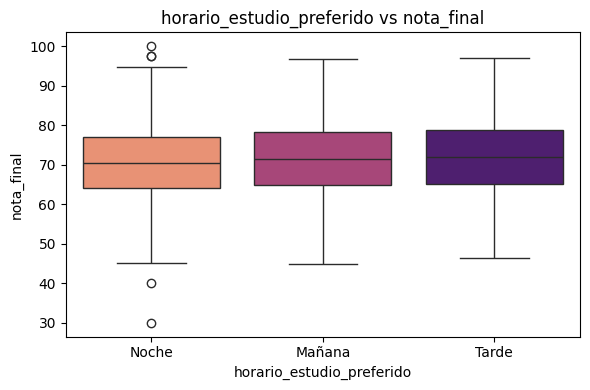

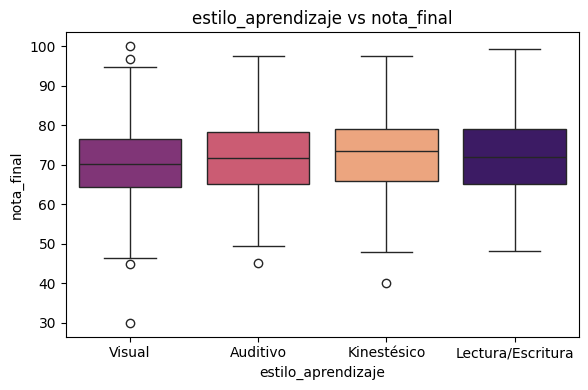

In [558]:
# Definir la variable objetivo
tv = 'nota_final'

# Generar gráficos independientes para cada variable categórica
for col in cat_cols:
    # Calcular el número de categorías únicas
    num_cats = df[col].nunique()

    # Ajustar dinámicamente el tamaño del gráfico
    fig_width = min(max(6, num_cats * 1.5), 25)  # Ancho mínimo de 6, máximo de 25
    fig_height = 4

    # Ordenar las categorías por el promedio de la variable objetivo
    ordered_cats = df.groupby(col)[tv].mean().sort_values().index

    plt.figure(figsize=(fig_width, fig_height))
    sns.boxplot(x=df[col], y=df[tv], hue=df[col], data=df, order=ordered_cats, palette="magma", legend=False)
    
    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.tight_layout()
    plt.show()

### Variable objetivo categórica `aprobado`

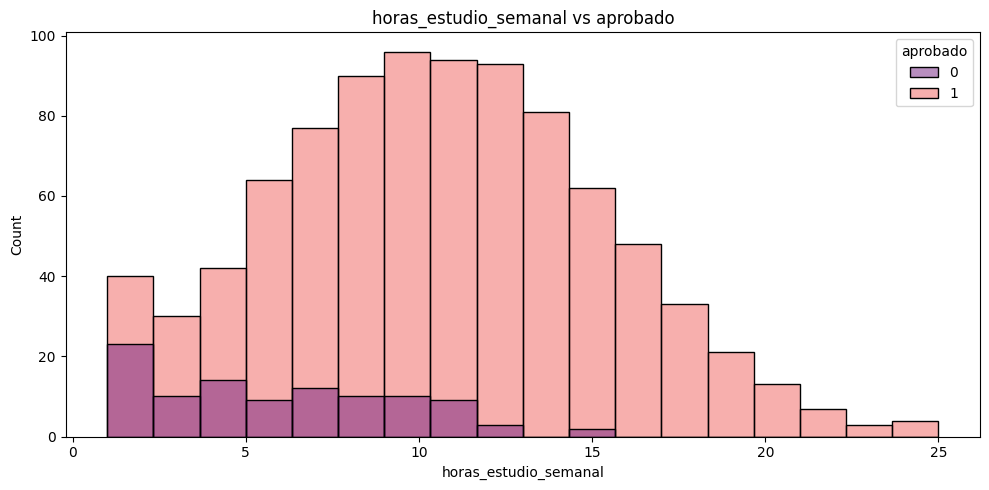

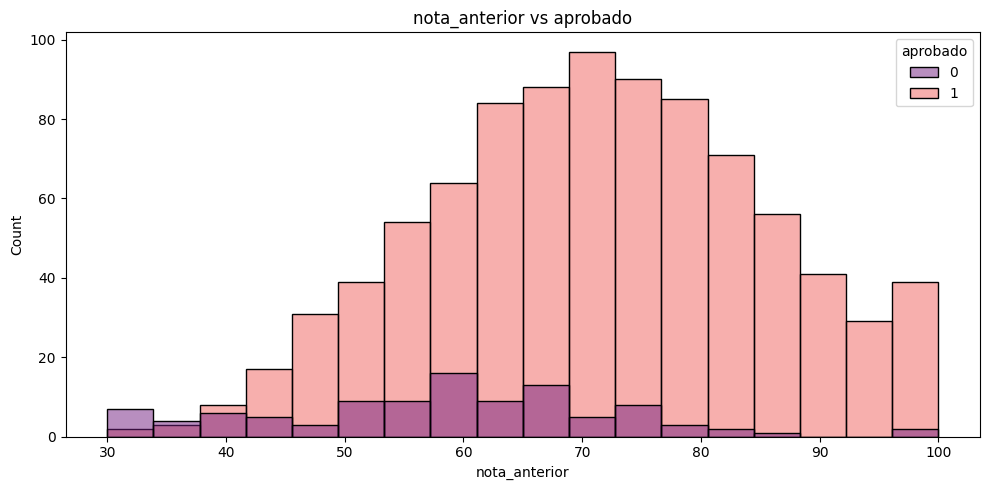

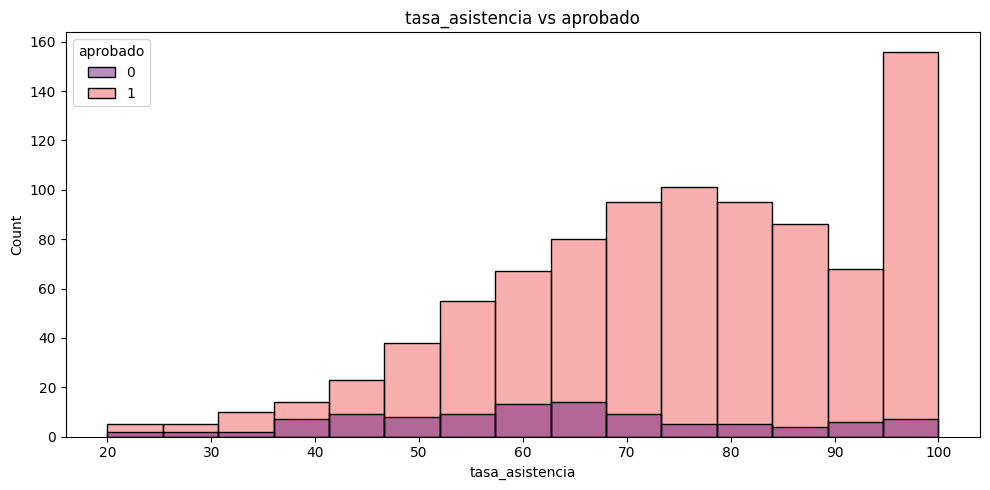

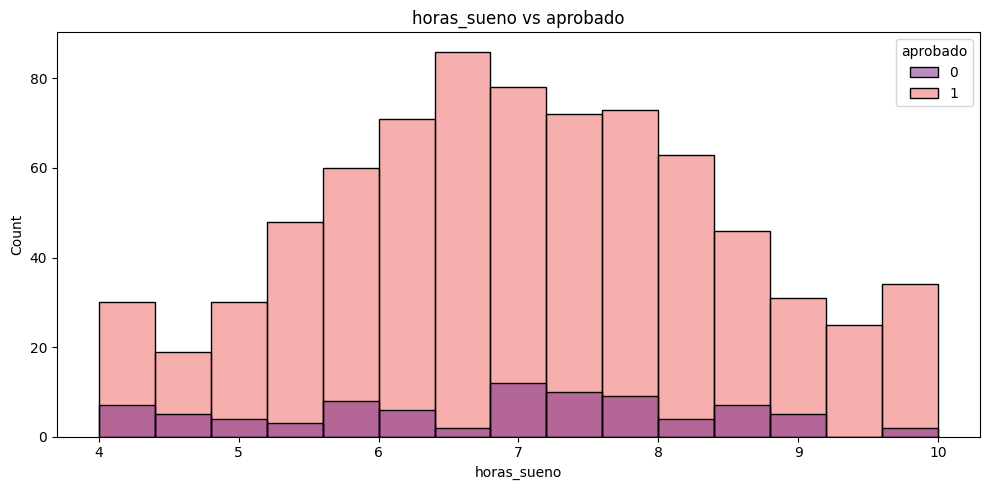

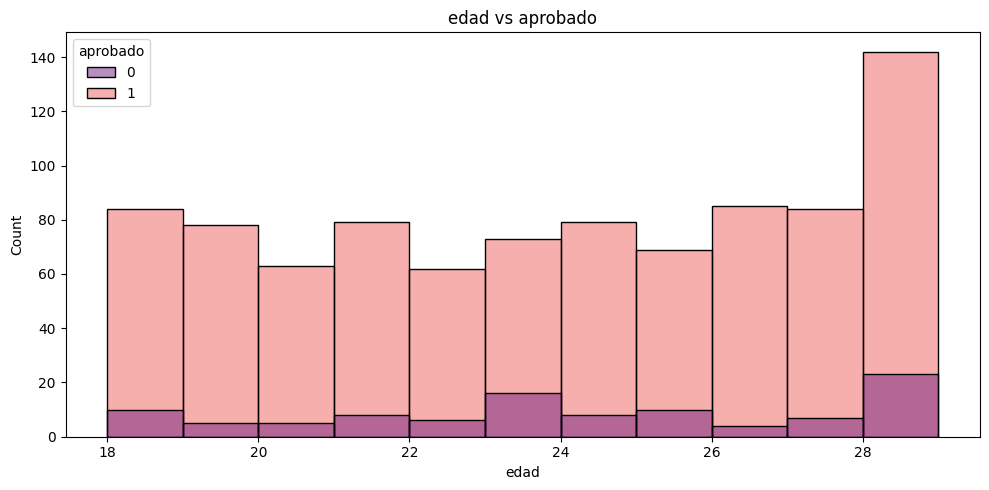

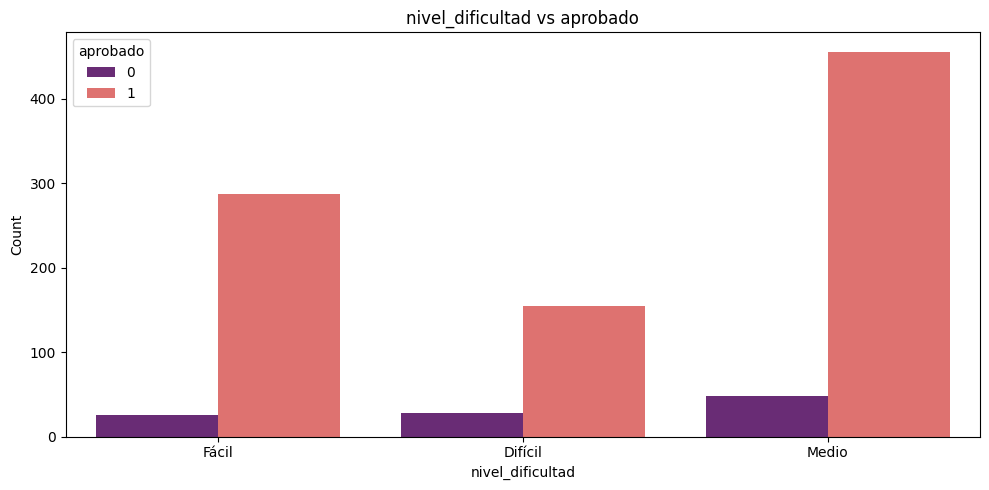

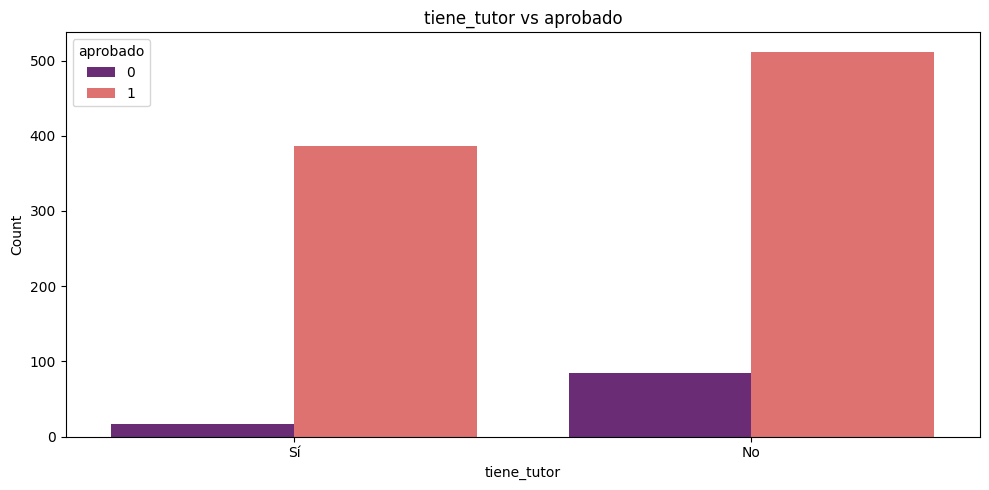

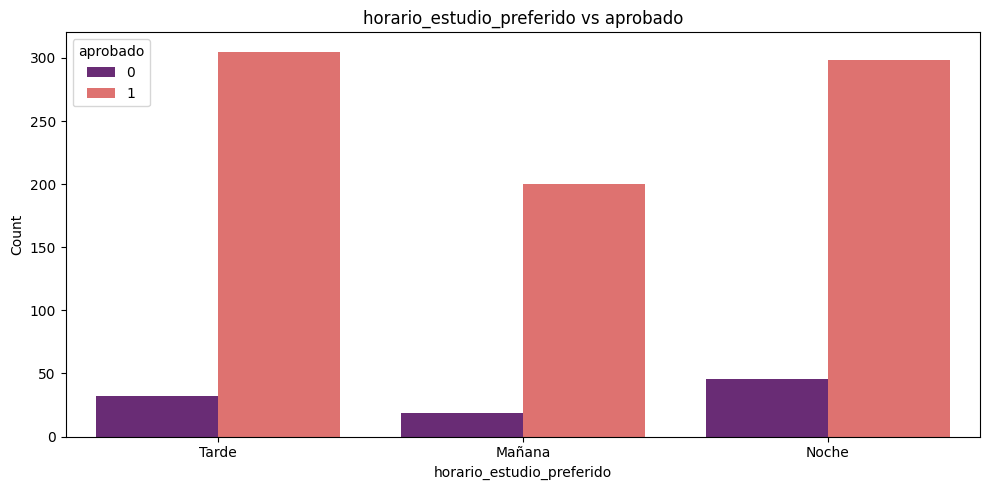

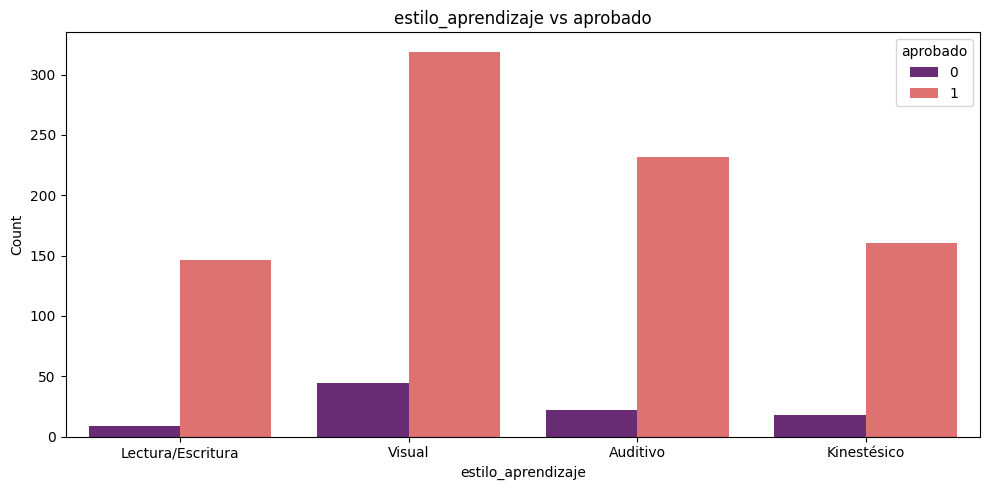

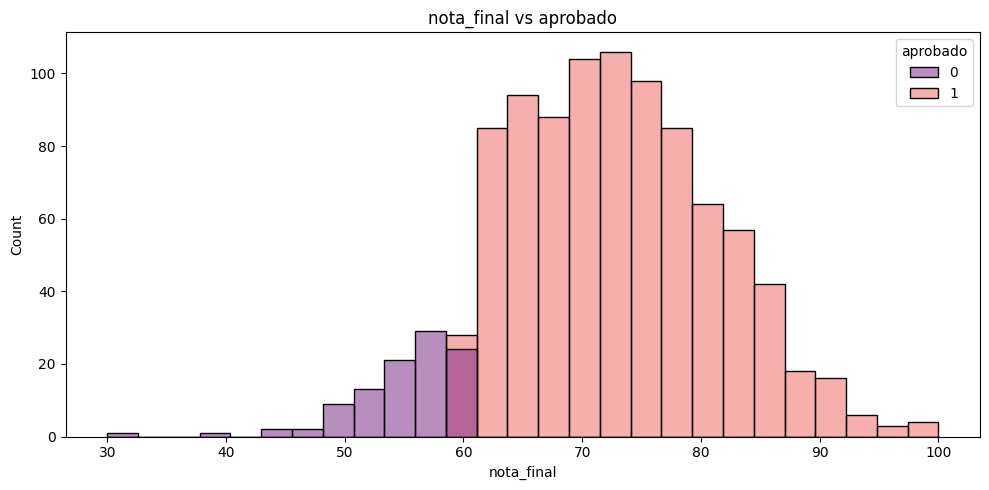

In [559]:
# Definir la variable objetivo
tv = 'aprobado'

for col in df.columns:
    # Saltar la variable objetivo
    if col == tv:
        continue

    plt.figure(figsize=(10, 5))

    if col in num_cols:
        sns.histplot(x=df[col], hue=df[tv], data=df, palette="magma", legend=True)
    elif col in cat_cols:
        sns.countplot(x=df[col], hue=df[tv], data=df, palette="magma")

    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Análisis de incosinstencias

In [560]:
# Lista para guardar inconsistencias
inconsistencies = []

# Regla 1: horas de estudio no pueden ser negativas
mask = df['horas_estudio_semanal'] < 0
for i in df.index[mask]:
    inconsistencies.append((i, 'horas_estudio_semanal negativa'))

# Regla 2: nota anterior debe estar entre 0 y 100
mask = (df['nota_anterior'] < 0) | (df['nota_anterior'] > 100)
for i in df.index[mask]:
    inconsistencies.append((i, 'nota_anterior fuera de 0-100'))

# Regla 3: tasa de asistencia debe estar entre 0 y 100
mask = (df['tasa_asistencia'] < 0) | (df['tasa_asistencia'] > 100)
for i in df.index[mask]:
    inconsistencies.append((i, 'tasa_asistencia fuera de 0-100'))

# Regla 4: horas de sueño deben estar entre 0 y 24
mask = (
    df['horas_sueno'].notna()
    & ((df['horas_sueno'] < 0) | (df['horas_sueno'] > 24))
)
for i in df.index[mask]:
    inconsistencies.append((i, 'horas_sueno fuera de 0-24'))

# Regla 5: edad no puede ser negativa
mask = df['edad'] < 0
for i in df.index[mask]:
    inconsistencies.append((i, 'edad negativa'))

# Regla 6: nota final debe estar entre 0 y 100
mask = (df['nota_final'] < 0) | (df['nota_final'] > 100)
for i in df.index[mask]:
    inconsistencies.append((i, 'nota_final fuera de 0-100'))

# Crear DataFrame con las inconsistencias
inconsistencies_df = pd.DataFrame(
    inconsistencies,
    columns=['Index', 'Inconsistency']
)

# Mostrar resultado
inconsistencies_df

,Index,Inconsistency


In [561]:
if not inconsistencies_df.empty:
    inconsistent_indices = inconsistencies_df['Index'].unique()
    df_inconsistent_rows = df.loc[inconsistent_indices]
    display(df_inconsistent_rows)
else:
    print("No se han detectado inconsistencias básicas.")

No se han detectado inconsistencias básicas.


### Conclusiones del análisis exploratorio

El análisis exploratorio realizado sobre el conjunto de datos, compuesto por **1.000 estudiantes y 11 variables**, permite concluir que el dataset presenta, en términos generales, una estructura adecuada para su posterior utilización en modelos de Machine Learning.

En primer lugar, no se han detectado **registros completamente duplicados**, ni tampoco inconsistencias básicas en las variables numéricas: las horas de estudio y la edad presentan valores positivos, las horas de sueño se encuentran dentro de límites posibles y tanto las notas como la tasa de asistencia se sitúan dentro del rango de 0 a 100.

Sí se han identificado **valores ausentes** en tres variables: `horas_sueno` presenta 150 valores nulos, `horario_estudio_preferido` 100 y `estilo_aprendizaje` 50. Estos valores deberán ser tratados durante la fase de preprocesamiento antes del entrenamiento de los modelos.

Respecto a las variables categóricas, predomina un **nivel de dificultad medio (50,4 %)** y aproximadamente el **40,3 % de los estudiantes dispone de tutor**. En cuanto al horario de estudio, las preferencias por la noche y la tarde son similares, mientras que el estilo de aprendizaje visual es el más frecuente.

El análisis de la variable `aprobado` muestra un **importante desequilibrio entre clases**, ya que el 89,8 % de los estudiantes están clasificados como aprobados frente al 10,2 % de no aprobados. Este aspecto deberá tenerse en cuenta posteriormente tanto en la división de los conjuntos de entrenamiento y prueba como en la elección de las métricas de evaluación del modelo de clasificación.

En relación con las variables numéricas, la `nota_final` presenta una media aproximada de **71,44 puntos**, mientras que la `nota_anterior` se sitúa alrededor de 69,89. Las horas de estudio semanales presentan una media cercana a 10 horas y la tasa de asistencia se sitúa aproximadamente en el 74 %.

El análisis de correlaciones muestra que las **horas de estudio semanal presentan una relación positiva relevante con la nota final**, mientras que otras variables, como la edad o las horas de sueño, muestran relaciones lineales bastante más reducidas. Asimismo, existe una asociación elevada entre `nota_final` y `aprobado`, algo esperable debido a que la condición de aprobado depende directamente de la calificación final. Por este motivo, ambas variables deberán separarse adecuadamente durante el modelado para evitar problemas de *data leakage*.

Finalmente, la detección de valores atípicos mediante los métodos IQR y Z-score identifica algunos casos extremos en variables como `horas_estudio_semanal`, `tasa_asistencia` y `nota_final`. No obstante, estos valores se encuentran dentro de rangos plausibles, por lo que no existe inicialmente una razón suficiente para eliminarlos automáticamente.

En conjunto, el EDA permite considerar que el dataset presenta una **calidad general adecuada**, siendo los principales aspectos a tratar en la siguiente fase la imputación de los valores nulos, la codificación de las variables categóricas, el tratamiento adecuado del desequilibrio de la variable objetivo y la prevención de posibles fugas de información antes del entrenamiento de los modelos.


### PREPROCESAMIENTO

In [562]:
# Manipulación de datos
import numpy as np
import pandas as pd
import math 

# Estadística y normalización
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [563]:
df = pd.read_csv(r"C:\Users\pchic\Downloads\dataset_estudiantes (2).csv")

In [564]:
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


In [565]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  900 non-null    str    
 8   estilo_aprendizaje         950 non-null    str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


### GESTION DE NULOS

In [566]:
# Identificación de valores nulos en el DataFrame
cantidad_nulos = df.isna().sum()  # Suma valores nulos por columna
cantidad_nulos = cantidad_nulos[cantidad_nulos != 0]  # Filtra solo columnas con valores nulos

cantidad_nulos  # Muestra el resultado

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

In [567]:
# Análisis de valores únicos en columnas categóricas con valores nulos
for col in cantidad_nulos.index.to_list():
    if col in df.select_dtypes(include='object'):
        display(df[col].value_counts())

C:\Users\pchic\AppData\Local\Temp\ipykernel_13860\2250260737.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if col in df.select_dtypes(include='object'):
C:\Users\pchic\AppData\Local\Temp\ipykernel_13860\2250260737.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration

horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

C:\Users\pchic\AppData\Local\Temp\ipykernel_13860\2250260737.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if col in df.select_dtypes(include='object'):


estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

### Imputación de nulos

Para las columnas categóricas (como estilo de aprendizaje, horario estudio favorito), se utiliza el valor genérico "Unknown" para reemplazar los valores nulos.
Para la columna numérica `horas de sueño`, se utiliza la mediana como medida de tendencia central para reemplazar los valores faltantes.

Esta estrategia de imputación preserva la integridad del conjunto de datos mientras proporciona un tratamiento apropiado según el tipo de variable, evitando la eliminación de filas con información parcialmente completa.

In [568]:
# Valor desconocido
val = 'Unknown'

# Columnas categoricas
cols_cat = ['horario_estudio_preferido','estilo_aprendizaje']

# Imputación de valores categóricos con un valor desconocido
df[cols_cat] = df[cols_cat].fillna(val)

# Imputación de valores numéricos con la mediana
df['horas_sueno'] = df['horas_sueno'].fillna(df['horas_sueno'].median())

In [569]:
# Comprobación de nulos
df.isna().sum().sum()

np.int64(0)

## Gestión outliers

### Identificación de outliers mediante boxplot

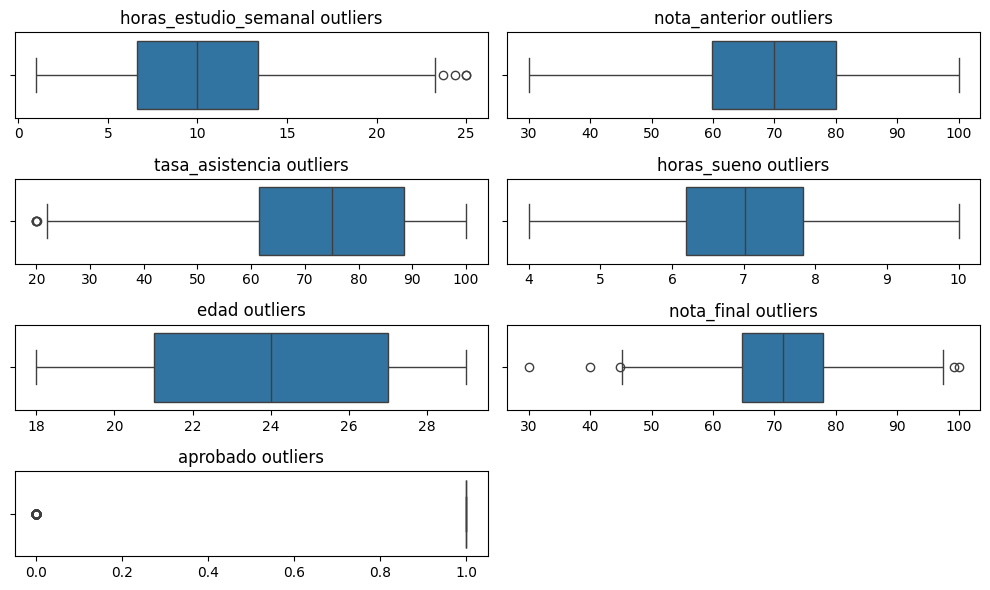

In [570]:
# Visualización de outliers en variables numéricas mediante diagramas de caja

# Seleccionar solo columnas numéricas del DataFrame
df_num = df.select_dtypes(include=np.number)
cols_num = df_num.columns

# Calcular el número de gráficos y filas necesarias
n_plots = len(cols_num)
num_rows = math.ceil(n_plots / 2)  # Se distribuyen en 2 columnas

# Ajustar dinámicamente el tamaño de la figura
width = 5 * 2
height = 1.5 * num_rows
size = (width, height)

# Crear la estructura de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=size)
axes = axes.flat  # Convertir matriz de ejes a lista plana

# Crear un boxplot para cada variable numérica
for i, col in enumerate(cols_num):
   sns.boxplot(
       x=col,
       data=df_num,
       ax=axes[i]
   )

   axes[i].set_title(f'{col} outliers')
   axes[i].set_xlabel('')  # Eliminar etiqueta del eje x para mayor claridad

# Eliminar el último gráfico si sobra un espacio vacío
if n_plots % 2 != 0:
   fig.delaxes(axes[-1])

# Ajustar el layout y mostrar la figura
plt.tight_layout()
plt.show()

### Detección de outliers mediante el método IQR

In [571]:
# Diccionario para almacenar los outliers detectados en cada columna
outliers_dict_iqr = {}

# Iterar sobre cada columna numérica
for col in df_num.columns:
   # Calcular los cuartiles Q1 y Q3
   Q1 = df_num[col].quantile(0.25)
   Q3 = df_num[col].quantile(0.75)
   IQR = Q3 - Q1  # Calcular el rango intercuartil

   # Definir los límites para detectar outliers (método de la valla)
   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

   # Filtrar los outliers en la columna actual
   outliers = df_num[(df_num[col] < lower_bound) | (df_num[col] > upper_bound)]
   
   # Almacenar los outliers en el diccionario
   outliers_dict_iqr[col] = outliers

In [572]:
outliers_dict_iqr['nota_final']

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado
323,1.000000,37.046592,24.764175,5.722487,18,40.0,0
579,1.000000,30.000000,64.240392,7.973087,29,30.0,0
606,16.609729,100.000000,100.000000,8.754101,27,99.2,1
822,2.432055,75.362436,84.842736,7.156477,27,44.9,0
927,14.827102,100.000000,72.812698,7.646091,18,100.0,1


### Detección de outliers mediante el método Z-score

In [573]:
# Diccionario para almacenar los outliers detectados en cada columna
outliers_dict_z = {}

for col in df_num.columns:

    # Filtrar los outliers usando |Z| > 3
    outliers = df_num[np.abs(zscore(df_num[col])) > 3]

    # Almacenar los outliers en el diccionario
    outliers_dict_z[col] = outliers

outliers_df = pd.concat(outliers_dict_z.values(), keys=outliers_dict_z.keys())


In [574]:
outliers_dict_z['nota_final'].shape

(2, 7)

## Para regresión

La variable objetivo es `nota_final`

In [575]:
df_reg = df.copy()

tv = 'nota_final'

# Eliminamos aprobado para evitar data leakage
df_reg = df_reg.drop(columns=['aprobado'])

In [576]:
# Variables categóricas
cat_cols = df_reg.select_dtypes(
    include=['object', 'string']
).columns.to_list()

cat_cols

['nivel_dificultad',
 'tiene_tutor',
 'horario_estudio_preferido',
 'estilo_aprendizaje']

### Codificación

Selección de los métodos de codificación

In [577]:
onehot_cols = ['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']
target_cols = [x for x in cat_cols if x not in onehot_cols]

`OneHotEncoding`

In [578]:
# Codificación OneHot
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_reg[onehot_cols])
onehot_feature_names = onehot_encoder.get_feature_names_out()
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_reg.index)

# Concatenar con el DataFrame original y eliminar las columnas originales
df_reg = pd.concat([df_reg.drop(columns=onehot_cols), df_onehot], axis=1)

### Guardamos el dataframe preprocesado

In [579]:
df_reg.to_csv('df_regresion.csv')

## Para clasificación

La variable objetivo es `Aprobado`

In [580]:
# Hacemos una copia del DataFrame
df_clas = df.copy()

# Seleccionamos la variable objetivo
tv = 'aprobado'

# Eliminamos nota_final para evitar data leakage
df_clas = df_clas.drop(columns=['nota_final'])

### Codificación

In [581]:
# Comprobamos las variables categóricas
cat_cols = df_clas.select_dtypes(
    include=['object', 'string']
).columns.to_list()

cat_cols

['nivel_dificultad',
 'tiene_tutor',
 'horario_estudio_preferido',
 'estilo_aprendizaje']

Selección de los métodos de codificación

In [582]:
# Variable binaria
df_clas['tiene_tutor'] = df_clas['tiene_tutor'].map({
    'No': 0,
    'Sí': 1
})

# Variable ordinal
df_clas['nivel_dificultad'] = df_clas['nivel_dificultad'].map({
    'Fácil': 1,
    'Medio': 2,
    'Difícil': 3
})

In [583]:
onehot_cols = [
    'horario_estudio_preferido',
    'estilo_aprendizaje'
]

In [584]:
onehot_encoder = OneHotEncoder(
    drop=None,
    sparse_output=False,
    handle_unknown='ignore'
)

onehot_encoded = onehot_encoder.fit_transform(
    df_clas[onehot_cols]
)

onehot_feature_names = onehot_encoder.get_feature_names_out(
    onehot_cols
)

df_onehot = pd.DataFrame(
    onehot_encoded,
    columns=onehot_feature_names,
    index=df_clas.index
)

df_clas = pd.concat(
    [
        df_clas.drop(columns=onehot_cols),
        df_onehot
    ],
    axis=1
)

In [585]:
df_clas.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,aprobado,horario_estudio_preferido_Mañana,horario_estudio_preferido_Noche,horario_estudio_preferido_Tarde,horario_estudio_preferido_Unknown,estilo_aprendizaje_Auditivo,estilo_aprendizaje_Kinestésico,estilo_aprendizaje_Lectura/Escritura,estilo_aprendizaje_Unknown,estilo_aprendizaje_Visual
0,8.957476,48.830601,86.640182,6.675694,25,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,11.042524,80.825707,83.449655,4.616844,18,3,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4.510776,90.383694,74.623607,7.755246,25,1,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6.647213,81.878257,82.849841,8.592826,23,1,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1.000000,66.254179,54.539935,6.671840,21,2,0,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [586]:
df_clas.isna().sum()

horas_estudio_semanal                   0
nota_anterior                           0
tasa_asistencia                         0
horas_sueno                             0
edad                                    0
nivel_dificultad                        0
tiene_tutor                             0
aprobado                                0
horario_estudio_preferido_Mañana        0
horario_estudio_preferido_Noche         0
horario_estudio_preferido_Tarde         0
horario_estudio_preferido_Unknown       0
estilo_aprendizaje_Auditivo             0
estilo_aprendizaje_Kinestésico          0
estilo_aprendizaje_Lectura/Escritura    0
estilo_aprendizaje_Unknown              0
estilo_aprendizaje_Visual               0
dtype: int64

In [587]:
df_clas.dtypes

horas_estudio_semanal                   float64
nota_anterior                           float64
tasa_asistencia                         float64
horas_sueno                             float64
edad                                      int64
nivel_dificultad                          int64
tiene_tutor                               int64
aprobado                                  int64
horario_estudio_preferido_Mañana        float64
horario_estudio_preferido_Noche         float64
horario_estudio_preferido_Tarde         float64
horario_estudio_preferido_Unknown       float64
estilo_aprendizaje_Auditivo             float64
estilo_aprendizaje_Kinestésico          float64
estilo_aprendizaje_Lectura/Escritura    float64
estilo_aprendizaje_Unknown              float64
estilo_aprendizaje_Visual               float64
dtype: object

### REGRESION

In [588]:
# Data processing  
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualization  
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection and evaluation  
# -----------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Regression models  
# -----------------------------------------------------------------------
from sklearn.linear_model import LinearRegression

# Metrics  
# -----------------------------------------------------------------------
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [589]:
# Separación entre variables predictoras y variable objetivo
X = df_reg.drop(columns=['nota_final'])
y = df_reg['nota_final']

In [590]:
# Dividimos los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostramos los tamaños de los conjuntos resultantes
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (800, 19)
Tamaño del conjunto de prueba: (200, 19)


In [591]:
# Variables numéricas que vamos a escalar
numeric_cols_reg = [
    'horas_estudio_semanal',
    'nota_anterior',
    'tasa_asistencia',
    'horas_sueno',
    'edad'
]

# Creamos el escalador
scaler_reg = MinMaxScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento
X_train[numeric_cols_reg] = scaler_reg.fit_transform(
    X_train[numeric_cols_reg]
)

# Transformamos los datos de test utilizando
# los parámetros aprendidos con entrenamiento
X_test[numeric_cols_reg] = scaler_reg.transform(
    X_test[numeric_cols_reg]
)

## Entrenamiento del modelo

In [592]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

In [593]:
# Ajustar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[16.79,11.93, 7.5 ,..., 0.55,-0.15,-0.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](19,)","['horas_estudio_semanal','nota_anterior','tasa_asistencia',..., 'estilo_aprendizaje_Lectura/Escritura','estilo_aprendizaje_Unknown', 'estilo_aprendizaje_Visual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,53.31
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


In [594]:
# Hacer predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

## Validación del modelo

### Comparación con scatterplot

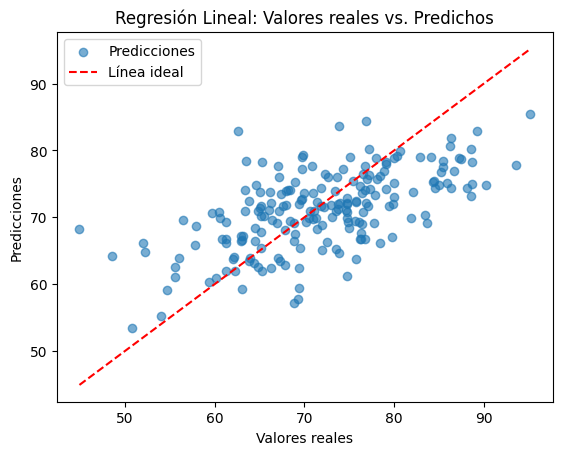

In [595]:
# Graficar valores reales vs. predichos
plt.scatter(y_test, y_pred, label="Predicciones", alpha=0.6)

# Agregar línea de referencia (y = x)
min_val = min(y_test.min(), y_pred.min())  # Valor mínimo entre reales y predichos
max_val = max(y_test.max(), y_pred.max())  # Valor máximo entre reales y predichos
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Línea ideal")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Valores reales vs. Predichos")
plt.legend()
plt.show()

### Comparación de distribuciones

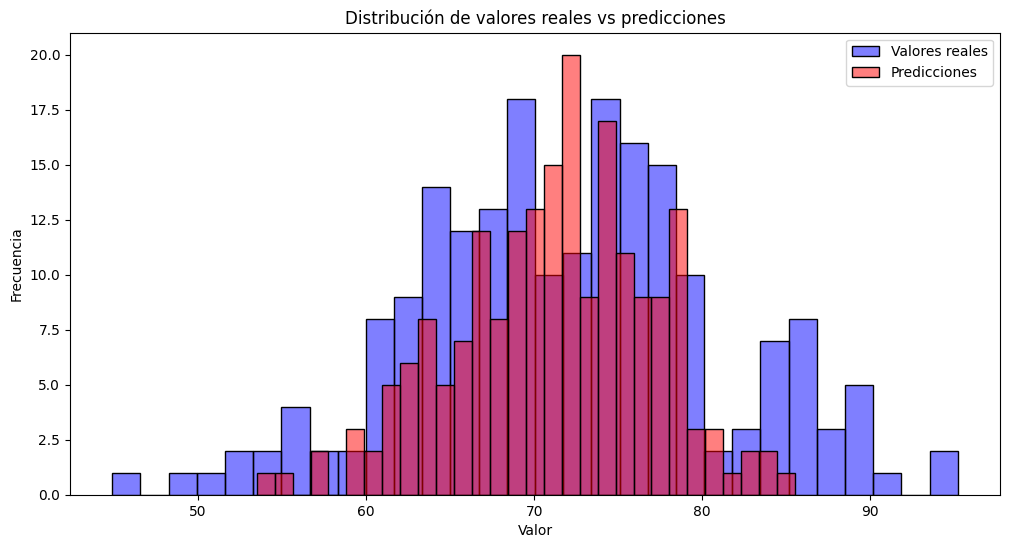

In [596]:
# Graficar valores reales vs. predichos
plt.figure(figsize=(12, 6))

n_bins = 30

# Histograma de y_test (azul)
sns.histplot(y_test, bins=n_bins, edgecolor='black', color='blue', alpha=0.5, label='Valores reales')

# Histograma de y_pred (rojo)
sns.histplot(y_pred, bins=n_bins, edgecolor='black', color='red', alpha=0.5, label='Predicciones')

plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Distribución de valores reales vs predicciones')
plt.legend()
plt.show()

### Residuos

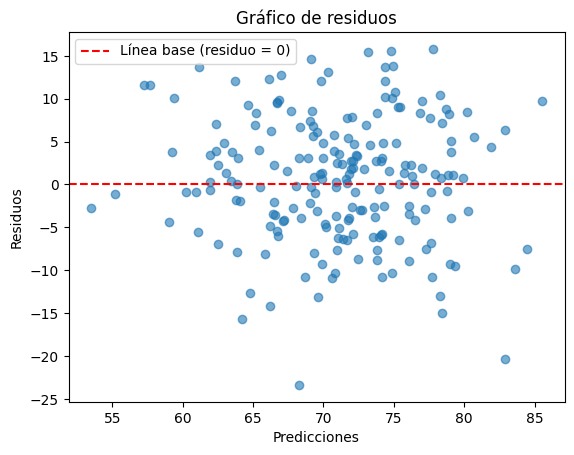

In [597]:
# Calcular los residuos
residuos = y_test - y_pred

# Graficar residuos
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--", label="Línea base (residuo = 0)")

# Etiquetas y título
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.legend()
plt.show()

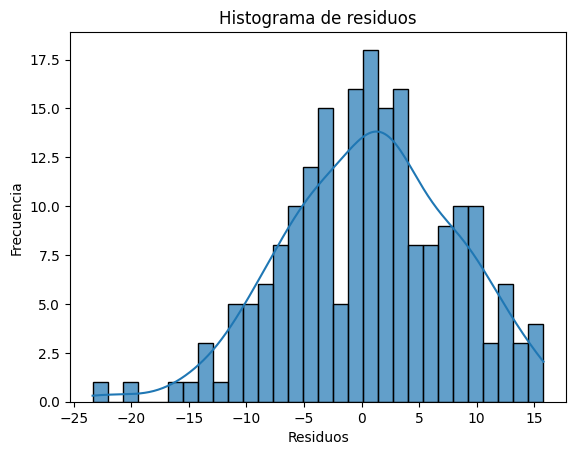

In [598]:
# Graficar histograma de los residuos
sns.histplot(residuos, bins=30, kde=True, edgecolor="black", alpha=0.7)

# Etiquetas y título
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos")

# Mostrar gráfico
plt.show()

## Importancia de características

In [599]:
# Crear DataFrame con los coeficientes
coef_df = pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient': modelo.coef_})
coef_df = coef_df.sort_values(by='Coefficient', key=abs)  # Ordenar por magnitud

In [600]:
coef_df.sort_values(by='Coefficient', ascending=False, key=abs)

,Feature,Coefficient
0,horas_estudio_semanal,16.789202
1,nota_anterior,11.929342
2,tasa_asistencia,7.500572
5,nivel_dificultad_Difícil,-1.557591
6,nivel_dificultad_Fácil,1.510378
13,horario_estudio_preferido_Unknown,1.127025
15,estilo_aprendizaje_Kinestésico,0.856800
18,estilo_aprendizaje_Visual,-0.799819
16,estilo_aprendizaje_Lectura/Escritura,0.552082
12,horario_estudio_preferido_Tarde,-0.467091


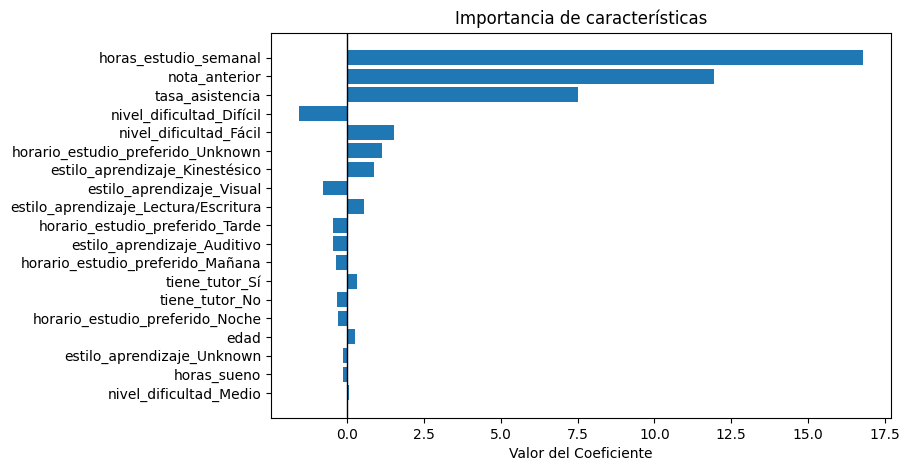

In [601]:
# Visualizar los coeficientes en un gráfico de barras
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel("Valor del Coeficiente")
plt.title("Importancia de características")
plt.axvline(0, color='black', linewidth=1)  # Línea en el 0 para referencia
plt.show()

## Métricas

In [602]:
# Predicciones
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

In [603]:
# Cálculo de métricas
metrics = {
    "train": {
        "R2": r2_score(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    },
    "test": {
        "R2": r2_score(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    },
}

# Mostrar métricas en un DataFrame
df_metrics = pd.DataFrame(metrics).T

In [604]:
df_metrics.round(2)

,R2,MAE,RMSE
train,0.39,6.03,7.55
test,0.36,5.82,7.25


## Entrenamiento final

In [605]:
import joblib

# Entrenar el modelo con todo el conjunto de datos
model_final = LinearRegression()
model_final.fit(X, y)

# Guardar el modelo entrenado para producción
joblib.dump(model_final, "modelo_regresion.pkl")

['modelo_regresion.pkl']

In [606]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Definir modelos con regularización
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

# Inicializar diccionario para métricas
metrics_results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenar el modelo

    # Predecir en entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calcular métricas
    metrics_results[name] = {
        "Train R²": r2_score(y_train, y_train_pred),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test R²": r2_score(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    }

# Convertir métricas a DataFrame
df_metrics = pd.DataFrame(metrics_results).T

In [607]:
df_metrics.round(2)

,Train R²,Train MAE,Train RMSE,Test R²,Test MAE,Test RMSE
Linear,0.39,6.03,7.55,0.36,5.82,7.25
Ridge,0.39,6.03,7.55,0.36,5.81,7.24
Lasso,0.38,6.06,7.60,0.37,5.85,7.19
ElasticNet,0.32,6.40,7.97,0.32,6.04,7.48


### CLASIFICACION

In [608]:
# Data processing
# -----------------------------------------------------------------------
import pandas as pd

# Visualization  
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection and evaluation  
# -----------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# Regression models  
# -----------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# Metrics  
# -----------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [609]:
# Separación entre variables predictoras y objetivo
X_clas = df_clas.drop(columns=['aprobado'])
y_clas = df_clas['aprobado']

In [610]:
X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_clas,
    y_clas,
    test_size=0.20,
    random_state=42,
    stratify=y_clas
)

In [611]:
numeric_cols_clas = [
    'horas_estudio_semanal',
    'nota_anterior',
    'tasa_asistencia',
    'horas_sueno',
    'edad',
    'nivel_dificultad'
]

scaler_clas = MinMaxScaler()

X_train_clas[numeric_cols_clas] = scaler_clas.fit_transform(
    X_train_clas[numeric_cols_clas]
)

X_test_clas[numeric_cols_clas] = scaler_clas.transform(
    X_test_clas[numeric_cols_clas]
)

In [612]:
# Crear una instancia de LogisticRegression
model = LogisticRegression(penalty='l2', C=1.0,  max_iter=200)

# Ajustar el modelo con los datos de entrenamiento
model.fit(X_train_clas, y_train_clas)

c:\Users\pchic\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To

In [613]:
# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test_clas)

In [614]:
# Obtener probabilidades de predicción
y_prob = model.predict_proba(X_test_clas)[:, 1]  # Probabilidad de la clase positiva

## Validación del modelo

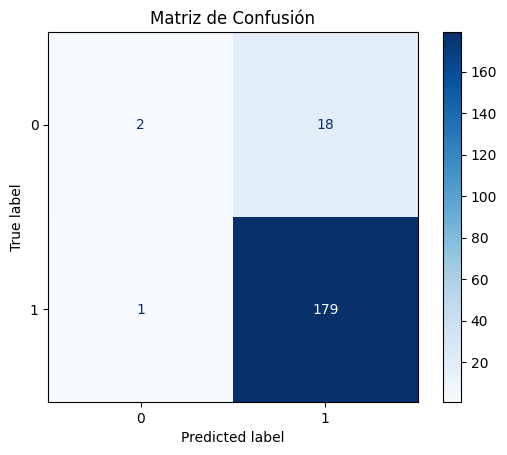

In [615]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test_clas, y_pred)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

## Métricas

In [616]:
# Calcular predicciones para el conjunto de entrenamiento y prueba
y_train_pred = model.predict(X_train_clas)
y_test_pred = model.predict(X_test_clas)

# Obtener las probabilidades de predicción
y_train_proba = model.predict_proba(X_train_clas)
y_test_proba = model.predict_proba(X_test_clas)

In [617]:
# Cálculo de métricas
metrics = {
    "train": {
        "Accuracy": accuracy_score(y_train_clas, y_train_pred),
        "Precision": precision_score(y_train_clas, y_train_pred),
        "Recall": recall_score(y_train_clas, y_train_pred),
        "F1-score": f1_score(y_train_clas, y_train_pred),
    },
    "test": {
        "Accuracy": accuracy_score(y_test_clas, y_test_pred),
        "Precision": precision_score(y_test_clas, y_test_pred),
        "Recall": recall_score(y_test_clas, y_test_pred),
        "F1-score": f1_score(y_test_clas, y_test_pred),
    },
}

# Mostrar métricas en un DataFrame
df_metrics = pd.DataFrame(metrics).T

df_metrics

,Accuracy,Precision,Recall,F1-score
train,0.9075,0.907595,0.998607,0.950928
test,0.9050,0.908629,0.994444,0.949602


In [618]:
df_metrics.round(2)

,Accuracy,Precision,Recall,F1-score
train,0.91,0.91,1.00,0.95
test,0.90,0.91,0.99,0.95


In [619]:
# Cálculo de métricas teniendo en cuenta el desbalanceo
metrics_weighted = {
    "train": {
        "Accuracy": accuracy_score(
            y_train_clas,
            y_train_pred
        ),
        "Precision": precision_score(
            y_train_clas,
            y_train_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_train_clas,
            y_train_pred,
            average="weighted",
            zero_division=0
        ),
        "F1-score": f1_score(
            y_train_clas,
            y_train_pred,
            average="weighted",
            zero_division=0
        ),
    },

    "test": {
        "Accuracy": accuracy_score(
            y_test_clas,
            y_test_pred
        ),
        "Precision": precision_score(
            y_test_clas,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_clas,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test_clas,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
    },
}

df_metrics_weighted = pd.DataFrame(metrics_weighted).T

df_metrics_weighted.round(3)

,Accuracy,Precision,Recall,F1-score
train,0.908,0.907,0.908,0.874
test,0.905,0.884,0.905,0.872


## Importancia de características

In [620]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo de clasificación
modelo_clas = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenar el modelo
modelo_clas.fit(
    X_train_clas,
    y_train_clas
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [621]:
modelo_clas

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [622]:
coef_df_clas = pd.DataFrame({
    'Feature': X_train_clas.columns,
    'Coefficient': modelo_clas.coef_[0]
})

coef_df_clas['Importancia_abs'] = coef_df_clas['Coefficient'].abs()

coef_df_clas = coef_df_clas.sort_values(
    by='Importancia_abs',
    ascending=False
)

coef_df_clas

,Feature,Coefficient,Importancia_abs
0,horas_estudio_semanal,2.726699,2.726699
1,nota_anterior,2.116489,2.116489
2,tasa_asistencia,1.764000,1.764000
5,nivel_dificultad,-0.768459,0.768459
10,horario_estudio_preferido_Unknown,0.657722,0.657722
8,horario_estudio_preferido_Noche,-0.413659,0.413659
14,estilo_aprendizaje_Unknown,-0.410971,0.410971
3,horas_sueno,0.390553,0.390553
4,edad,-0.379738,0.379738
13,estilo_aprendizaje_Lectura/Escritura,0.356413,0.356413


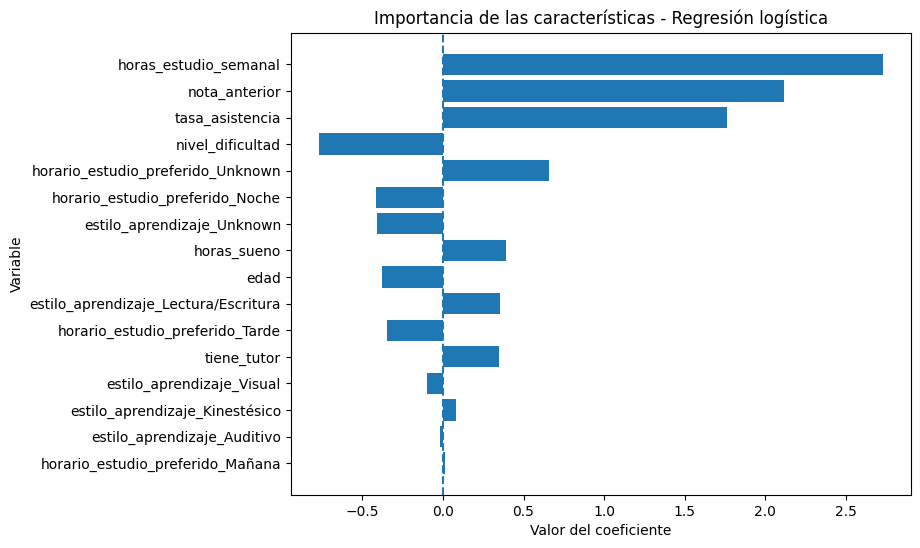

In [623]:
plt.figure(figsize=(8, 6))

plt.barh(
    coef_df_clas['Feature'],
    coef_df_clas['Coefficient']
)

plt.xlabel("Valor del coeficiente")
plt.ylabel("Variable")
plt.title("Importancia de las características - Regresión logística")

plt.axvline(
    x=0,
    linestyle='--'
)

plt.gca().invert_yaxis()

plt.show()

## Entrenamiento final

In [624]:
import joblib

# Copia de los datos completos
X_final_clas = X_clas.copy()

# Escalado final utilizando todo el conjunto
scaler_final_clas = MinMaxScaler()

X_final_clas[numeric_cols_clas] = scaler_final_clas.fit_transform(
    X_final_clas[numeric_cols_clas]
)

# Modelo final elegido: Logistic L2
model_final_clas = LogisticRegression(
    C=1.0,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Entrenamiento con todos los datos
model_final_clas.fit(
    X_final_clas,
    y_clas
)

# Guardar modelo y escalador
joblib.dump(
    model_final_clas,
    "modelo_clasificacion.pkl"
)

joblib.dump(
    scaler_final_clas,
    "scaler_clasificacion.pkl"
)

['scaler_clasificacion.pkl']

In [625]:
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Definir modelos de regresión logística con distintos tipos de regularización
models_clas = {
    
    "Logistic (L2 - Ridge)": LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),

    "Logistic (L1 - Lasso)": LogisticRegression(
        penalty='l1',
        C=0.1,
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ),

    "Logistic (ElasticNet)": LogisticRegression(
        penalty='elasticnet',
        C=0.1,
        l1_ratio=0.5,
        solver='saga',
        max_iter=1000,
        random_state=42
    )
}


# Inicializar diccionario para almacenar las métricas
metrics_results_clas = {}


# Entrenar y evaluar cada modelo
for name, model in models_clas.items():

    # Entrenar el modelo
    model.fit(
        X_train_clas,
        y_train_clas
    )

    # Predicciones sobre entrenamiento y test
    y_train_pred = model.predict(X_train_clas)
    y_test_pred = model.predict(X_test_clas)

    # Calcular métricas ponderadas
    metrics_results_clas[name] = {

        "Train Accuracy": accuracy_score(
            y_train_clas,
            y_train_pred
        ),

        "Train Precision (Weighted)": precision_score(
            y_train_clas,
            y_train_pred,
            average='weighted',
            zero_division=0
        ),

        "Train Recall (Weighted)": recall_score(
            y_train_clas,
            y_train_pred,
            average='weighted',
            zero_division=0
        ),

        "Train F1 (Weighted)": f1_score(
            y_train_clas,
            y_train_pred,
            average='weighted',
            zero_division=0
        ),

        "Test Accuracy": accuracy_score(
            y_test_clas,
            y_test_pred
        ),

        "Test Precision (Weighted)": precision_score(
            y_test_clas,
            y_test_pred,
            average='weighted',
            zero_division=0
        ),

        "Test Recall (Weighted)": recall_score(
            y_test_clas,
            y_test_pred,
            average='weighted',
            zero_division=0
        ),

        "Test F1 (Weighted)": f1_score(
            y_test_clas,
            y_test_pred,
            average='weighted',
            zero_division=0
        )
    }


# Convertir los resultados en DataFrame
df_metrics_clas = pd.DataFrame(metrics_results_clas).T

# Mostrar resultados
df_metrics_clas.round(3)

c:\Users\pchic\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\pchic\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Train Accuracy,Train Precision (Weighted),Train Recall (Weighted),Train F1 (Weighted),Test Accuracy,Test Precision (Weighted),Test Recall (Weighted),Test F1 (Weighted)
Logistic (L2 - Ridge),0.906,0.905,0.906,0.871,0.91,0.918,0.91,0.875
Logistic (L1 - Lasso),0.898,0.806,0.898,0.849,0.90,0.810,0.90,0.853
Logistic (ElasticNet),0.898,0.806,0.898,0.849,0.90,0.810,0.90,0.853


In [626]:
df_metrics_clas.round(3)

,Train Accuracy,Train Precision (Weighted),Train Recall (Weighted),Train F1 (Weighted),Test Accuracy,Test Precision (Weighted),Test Recall (Weighted),Test F1 (Weighted)
Logistic (L2 - Ridge),0.906,0.905,0.906,0.871,0.91,0.918,0.91,0.875
Logistic (L1 - Lasso),0.898,0.806,0.898,0.849,0.90,0.810,0.90,0.853
Logistic (ElasticNet),0.898,0.806,0.898,0.849,0.90,0.810,0.90,0.853


In [627]:
# Seleccionamos el mejor modelo
mejor_modelo_clas = models_clas["Logistic (L2 - Ridge)"]

# Predicciones del mejor modelo
y_test_pred_mejor = mejor_modelo_clas.predict(X_test_clas)

In [628]:
print(
    classification_report(
        y_test_clas,
        y_test_pred_mejor,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.10      0.18        20
           1       0.91      1.00      0.95       180

    accuracy                           0.91       200
   macro avg       0.95      0.55      0.57       200
weighted avg       0.92      0.91      0.88       200



In [630]:
balanced_accuracy = balanced_accuracy_score(
    y_test_clas,
    y_test_pred_mejor
)

print(
    "Balanced Accuracy:",
    round(balanced_accuracy, 3)
)

Balanced Accuracy: 0.55


In [631]:
class_weight='balanced'

In [632]:
modelo_balanceado = LogisticRegression(
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_balanceado.fit(
    X_train_clas,
    y_train_clas
)

y_pred_balanceado = modelo_balanceado.predict(
    X_test_clas
)

print(
    classification_report(
        y_test_clas,
        y_pred_balanceado,
        zero_division=0
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test_clas,
            y_pred_balanceado
        ),
        3
    )
)

              precision    recall  f1-score   support

           0       0.20      0.65      0.31        20
           1       0.95      0.72      0.82       180

    accuracy                           0.71       200
   macro avg       0.58      0.68      0.56       200
weighted avg       0.87      0.71      0.77       200

Balanced Accuracy: 0.683


# Informe de resultados del proyecto de Machine Learning

## 1. Objetivo del análisis

El objetivo del proyecto consiste en aplicar técnicas de Machine Learning a un conjunto de datos de 1.000 estudiantes con el propósito de abordar dos problemas predictivos diferentes.

Por una parte, se plantea un problema de **regresión**, cuyo objetivo es predecir la `nota_final` de cada estudiante, expresada como una variable continua entre 0 y 100. Por otra, se desarrolla un problema de **clasificación**, dirigido a predecir si el estudiante aprobará o no, utilizando como variable objetivo `aprobado`, que toma el valor 1 cuando la nota final es igual o superior a 60 y 0 en caso contrario.

Las variables predictoras disponibles contienen información sobre las horas semanales de estudio, la nota obtenida anteriormente, la tasa de asistencia, las horas de sueño, la edad, el nivel de dificultad percibido, la existencia o no de tutor, el horario preferido de estudio y el estilo de aprendizaje.

---

## 2. Análisis exploratorio de los datos

El análisis exploratorio permitió comprobar inicialmente la estructura y calidad del conjunto de datos.

El dataset contiene **1.000 observaciones y 11 variables**. No se identificaron registros completamente duplicados ni inconsistencias básicas en los valores numéricos. Las notas y la tasa de asistencia se encuentran dentro del intervalo de 0 a 100, las edades son positivas y las horas de sueño presentan valores plausibles.

Sí se detectaron valores ausentes en tres variables:

* `horas_sueno`: 150 valores ausentes.
* `horario_estudio_preferido`: 100 valores ausentes.
* `estilo_aprendizaje`: 50 valores ausentes.

En cuanto a las principales características de la muestra, la nota final media se sitúa aproximadamente en **71,44 puntos**, mientras que la nota anterior presenta una media cercana a **69,89 puntos**. Los alumnos estudian de media alrededor de 10 horas semanales y presentan una tasa de asistencia próxima al 74 %.

Entre las variables categóricas, el nivel de dificultad medio es el más frecuente, representando aproximadamente el **50,4 % de los estudiantes**, y alrededor del **40,3 % dispone de tutor**.

Uno de los resultados más relevantes del análisis exploratorio se encuentra en la variable `aprobado`. Aproximadamente el **89,8 % de los estudiantes aprueba**, frente a únicamente un **10,2 % que suspende**. Por tanto, existe un importante **desbalanceo de clases**, circunstancia especialmente relevante para la posterior evaluación de los modelos de clasificación.

El análisis de correlaciones mostró además que las **horas semanales de estudio presentan una relación positiva relevante con la nota final**. La nota anterior y la asistencia también contienen una señal predictiva importante, mientras que variables como la edad o las horas de sueño presentan una relación lineal bastante más reducida.

Asimismo, existe una asociación muy elevada entre `nota_final` y `aprobado`. Esto resulta lógico porque la segunda variable se construye directamente a partir de la primera. Precisamente por ello, durante el modelado fue necesario evitar que una de estas variables se utilizara para predecir la otra, ya que se produciría una fuga de información o *data leakage*.

Finalmente, mediante los métodos IQR y Z-score se identificaron algunos valores atípicos. Sin embargo, estos valores resultaron posibles dentro del contexto del problema. Por ejemplo, se observaron notas finales extremas próximas a 30 o 100 puntos, pero no valores imposibles. En consecuencia, se decidió no eliminar automáticamente estas observaciones.

---

## 3. Preprocesamiento de los datos

Antes del entrenamiento de los modelos se realizó una fase de preparación del conjunto de datos.

Los valores ausentes de las variables categóricas `horario_estudio_preferido` y `estilo_aprendizaje` fueron sustituidos por la categoría `"Unknown"`. Esta solución permite conservar las observaciones y, al mismo tiempo, diferenciar expresamente aquellos casos en los que la información original no estaba disponible.

Los valores ausentes de `horas_sueno` fueron sustituidos por la mediana de la variable. Tras este proceso se comprobó que el conjunto de datos no contenía valores nulos.

Las variables categóricas fueron posteriormente transformadas a formato numérico para poder ser utilizadas por los algoritmos de Machine Learning.

En el problema de regresión se aplicó **One-Hot Encoding** a las variables categóricas. Para clasificación, `tiene_tutor` se convirtió en una variable binaria, `nivel_dificultad` se codificó ordinalmente y se aplicó One-Hot Encoding al horario preferido y al estilo de aprendizaje.

También se adoptaron medidas específicas para evitar *data leakage*. En regresión se eliminó `aprobado` antes de predecir `nota_final`, mientras que en clasificación se eliminó `nota_final` antes de predecir `aprobado`.

Finalmente, los datos se dividieron en conjuntos de entrenamiento y prueba, utilizando aproximadamente un **80 % para entrenamiento y un 20 % para test**. En clasificación se utilizó además una división estratificada para mantener una proporción semejante de aprobados y suspensos en ambos conjuntos.

Las variables numéricas fueron normalizadas mediante `MinMaxScaler`. El escalador se ajustó exclusivamente con los datos de entrenamiento y posteriormente se aplicó al conjunto de test, evitando así utilizar información del conjunto de prueba durante el entrenamiento.

---

# 4. Modelo de regresión

## 4.1. Regresión lineal

El primer objetivo consiste en estimar la nota final del estudiante.

Como modelo inicial se utilizó una **regresión lineal múltiple**, entrenada con las distintas características disponibles del estudiante.

Los resultados obtenidos fueron los siguientes:

| Métrica | Entrenamiento | Test |
| ------- | ------------: | ---: |
| R²      |          0,39 | 0,36 |
| MAE     |          6,03 | 5,82 |
| RMSE    |          7,55 | 7,25 |

### Interpretación del R²

El coeficiente de determinación obtenido en test es:

**R² = 0,36**

Esto significa que el modelo consigue explicar aproximadamente el **36 % de la variabilidad observada en las notas finales**.

La capacidad explicativa puede considerarse moderada. No se trata de un modelo capaz de explicar completamente el rendimiento académico, pero sí consigue extraer una señal relevante de las variables disponibles.

Debe tenerse en cuenta que el rendimiento de un estudiante puede depender de numerosos factores no recogidos en el dataset, como la dificultad específica del examen, la motivación, los conocimientos previos, la capacidad individual, el método real de estudio o circunstancias personales.

### Interpretación del MAE

El error absoluto medio obtenido es:

**MAE = 5,82**

Esto significa que, en promedio, la predicción realizada por el modelo se desvía aproximadamente **5,8 puntos de la nota final real**, sobre una escala de 0 a 100.

Esta métrica resulta especialmente intuitiva para interpretar el modelo. Por ejemplo, si un estudiante obtiene realmente un 75, el modelo podría predecir aproximadamente un 69 o un 81 manteniéndose dentro del error medio observado.

### Interpretación del RMSE

El modelo obtiene:

**RMSE = 7,25**

El RMSE penaliza en mayor medida los errores grandes. Su valor superior al MAE indica que existen determinadas observaciones en las que la diferencia entre la nota real y la predicha es considerablemente superior al error medio.

### Generalización del modelo

Resulta especialmente positivo que las métricas de entrenamiento y test sean muy similares:

* R² Train: 0,39.
* R² Test: 0,36.

Esta proximidad indica que **no existe evidencia clara de sobreajuste**. El modelo presenta un comportamiento semejante cuando predice alumnos utilizados en el entrenamiento y cuando se enfrenta a observaciones no utilizadas anteriormente.

---

## 4.2. Importancia de las variables en regresión

Los coeficientes muestran que las variables con mayor influencia son:

1. `horas_estudio_semanal`: coeficiente aproximado de **+16,79**.
2. `nota_anterior`: aproximadamente **+11,93**.
3. `tasa_asistencia`: aproximadamente **+7,50**.

Por tanto, el modelo identifica las horas de estudio, el rendimiento anterior y la asistencia como los principales factores predictivos de la nota final.

El nivel de dificultad también tiene cierta influencia. La categoría difícil presenta un coeficiente negativo, mientras que la categoría fácil presenta un coeficiente positivo.

Las restantes variables, como edad, horas de sueño, existencia de tutor, horario preferido o estilo de aprendizaje, presentan coeficientes considerablemente menores.

Debe tenerse en cuenta que las variables numéricas fueron previamente normalizadas. Por ello, un coeficiente como +16,79 para las horas de estudio **no significa que una hora adicional de estudio aumente directamente la nota en 16,79 puntos**. El coeficiente representa el efecto asociado a la variación de la variable una vez transformada a la escala utilizada por el modelo.

---

## 4.3. Comparación de modelos de regresión

Para comprobar si la regularización mejoraba el modelo se compararon cuatro alternativas:

| Modelo     |  R² Test | MAE Test | RMSE Test |
| ---------- | -------: | -------: | --------: |
| Linear     |     0,36 |     5,82 |      7,25 |
| Ridge      |     0,36 | **5,81** |      7,24 |
| Lasso      | **0,37** |     5,85 |  **7,19** |
| ElasticNet |     0,32 |     6,04 |      7,48 |

Los resultados muestran que **Linear, Ridge y Lasso presentan rendimientos muy similares**.

Lasso obtiene el mayor R², con aproximadamente 0,37, y el menor RMSE, con 7,19. Ridge obtiene ligeramente el menor MAE, con 5,81.

Sin embargo, las diferencias son pequeñas, por lo que no puede afirmarse que alguno de estos modelos sea sustancialmente superior a los demás.

ElasticNet presenta un rendimiento inferior, con un R² de aproximadamente 0,32.

La conclusión principal es que la regularización no produce una mejora sustancial del modelo. Esto sugiere que el problema no parece derivarse principalmente de un exceso de variables o de sobreajuste, sino probablemente de las propias limitaciones de la información disponible y del carácter parcialmente no lineal del rendimiento académico.

---

# 5. Modelo de clasificación

El segundo objetivo consiste en predecir si el alumno aprobará o suspenderá.

Se utilizó como modelo inicial una **regresión logística**.

La variable objetivo presenta dos categorías:

* `0`: alumno suspenso.
* `1`: alumno aprobado.

La distribución de clases está fuertemente desequilibrada, ya que cerca del 90 % de los alumnos pertenece a la clase 1.

---

## 5.1. Resultados globales

El modelo inicial obtiene en test aproximadamente:

| Métrica   | Resultado |
| --------- | --------: |
| Accuracy  |     0,905 |
| Precision |     0,909 |
| Recall    |     0,994 |
| F1-score  |     0,950 |

A primera vista, estas cifras parecen indicar un modelo extraordinariamente preciso.

Sin embargo, estas métricas están fuertemente condicionadas por el predominio de la clase de aprobados.

Al calcular las métricas ponderadas se obtiene:

| Métrica ponderada |  Test |
| ----------------- | ----: |
| Accuracy          | 0,905 |
| Precision         | 0,884 |
| Recall            | 0,905 |
| F1-score          | 0,872 |

La diferencia confirma la necesidad de analizar el comportamiento de cada clase por separado.

---

## 5.2. Importancia de las variables

Los coeficientes de la regresión logística vuelven a identificar las mismas tres variables como principales predictores:

* `horas_estudio_semanal`: coeficiente aproximado de **+2,73**.
* `nota_anterior`: aproximadamente **+2,12**.
* `tasa_asistencia`: aproximadamente **+1,76**.

Los coeficientes positivos indican que, manteniendo constantes las demás variables, valores superiores están asociados a una mayor probabilidad estimada de aprobar.

Por el contrario, `nivel_dificultad` presenta un coeficiente negativo cercano a **−0,77**, indicando que una mayor dificultad se relaciona con una menor probabilidad estimada de aprobar.

Por tanto, existe una notable coherencia entre los resultados de regresión y clasificación: **horas de estudio, rendimiento previo y asistencia constituyen las variables con mayor poder predictivo**.

---

# 6. Comparación de modelos de clasificación

Se compararon tres versiones de regresión logística con diferentes tipos de regularización:

| Modelo              | Accuracy Test | Precision weighted | Recall weighted | F1 weighted |
| ------------------- | ------------: | -----------------: | --------------: | ----------: |
| Logistic L2 - Ridge |      **0,91** |          **0,918** |        **0,91** |   **0,875** |
| Logistic L1 - Lasso |          0,90 |              0,810 |            0,90 |       0,853 |
| Logistic ElasticNet |          0,90 |              0,810 |            0,90 |       0,853 |

La regresión logística con penalización **L2** presenta el mejor resultado global.

Sin embargo, el análisis por clases revela una limitación muy importante.

Para el modelo L2 se obtiene:

| Clase        | Precision |   Recall |   F1 |
| ------------ | --------: | -------: | ---: |
| Suspenso (0) |      1,00 | **0,10** | 0,18 |
| Aprobado (1) |      0,91 | **1,00** | 0,95 |

La accuracy global alcanza aproximadamente el **91 %**, pero el modelo solo identifica correctamente alrededor del **10 % de los estudiantes que suspenden**.

En un conjunto de test formado por 200 alumnos, aproximadamente 20 son suspensos y 180 aprobados. El modelo identifica prácticamente todos los aprobados, pero únicamente una pequeña parte de los suspensos.

Por este motivo, la **Balanced Accuracy** es únicamente:

**0,55**

Esta métrica asigna la misma importancia a ambas clases y muestra que el comportamiento real del modelo es considerablemente menos satisfactorio de lo que podría sugerir la accuracy del 91 %.

Este resultado constituye una de las principales conclusiones del proyecto: **una elevada accuracy no garantiza necesariamente un buen modelo cuando existe un fuerte desbalanceo entre clases**.

---

# 7. Tratamiento del desbalanceo: `class_weight='balanced'`

Para estudiar esta limitación se entrenó adicionalmente una regresión logística asignando pesos automáticamente equilibrados a las clases mediante:

`class_weight='balanced'`.

El objetivo de este modelo no consiste necesariamente en maximizar la accuracy global, sino en prestar mayor atención a la clase minoritaria de alumnos suspensos.

Los resultados obtenidos fueron:

| Clase        | Precision |   Recall |   F1 |
| ------------ | --------: | -------: | ---: |
| Suspenso (0) |      0,20 | **0,65** | 0,31 |
| Aprobado (1) |      0,95 |     0,72 | 0,82 |

Las métricas globales fueron:

* Accuracy: **0,71**.
* Balanced Accuracy: **0,683**.

El resultado muestra claramente el compromiso existente entre las diferentes métricas.

El modelo convencional L2 obtenía:

* Accuracy: 0,91.
* Recall suspensos: 0,10.
* Balanced Accuracy: 0,55.

Mientras que el modelo balanceado obtiene:

* Accuracy: 0,71.
* Recall suspensos: **0,65**.
* Balanced Accuracy: **0,683**.

Por tanto, el modelo balanceado sacrifica una parte importante de la exactitud global, pero aumenta de forma muy considerable la capacidad para detectar estudiantes en riesgo de suspender.

El recall de la clase 0 pasa del **10 % al 65 %**.

Esta diferencia tiene una interpretación práctica muy importante. Si el objetivo del sistema fuese identificar estudiantes susceptibles de necesitar apoyo académico, el modelo balanceado podría resultar más útil, incluso aunque presente una menor accuracy global.

Por el contrario, si el único objetivo fuese maximizar el porcentaje total de predicciones correctas, el modelo L2 convencional sería superior.

Por tanto, **la elección del modelo no debe realizarse únicamente a partir de una única métrica, sino en función del objetivo real del problema**.

---

# 8. Conclusiones generales

El análisis permite extraer varias conclusiones relevantes.

En primer lugar, el conjunto de datos presenta una calidad suficiente para desarrollar modelos predictivos después del tratamiento de los valores ausentes y de la transformación de las variables categóricas.

En segundo lugar, tanto la regresión como la clasificación identifican de forma consistente tres variables fundamentales:

1. **Horas semanales de estudio.**
2. **Nota anterior.**
3. **Tasa de asistencia.**

Estas variables presentan la mayor capacidad predictiva sobre el rendimiento académico.

En el problema de regresión, los modelos explican aproximadamente entre el **36 % y el 37 % de la variabilidad de la nota final**. El error absoluto medio se sitúa alrededor de **5,8 puntos**, y la proximidad entre las métricas de entrenamiento y test indica que no existe un problema evidente de sobreajuste.

Lasso obtiene ligeramente el mejor R² y RMSE, aunque las diferencias respecto a Linear y Ridge son reducidas. Por tanto, no existe una mejora sustancial derivada de la regularización.

En clasificación, la regresión logística L2 alcanza una accuracy cercana al **91 %**, pero esta cifra está fuertemente condicionada por el predominio de alumnos aprobados.

El análisis individual de las clases demuestra que el modelo convencional presenta una elevada capacidad para detectar aprobados, pero una capacidad muy limitada para detectar suspensos, obteniendo un recall de únicamente el **10 %** para esta última clase.

La introducción de pesos balanceados modifica sustancialmente este comportamiento. La accuracy global disminuye hasta aproximadamente el **71 %**, pero el recall de los suspensos aumenta hasta el **65 %** y la Balanced Accuracy pasa de **0,55 a 0,683**.

Por tanto, no existe un único modelo universalmente superior. La elección depende del objetivo perseguido:

* Si se pretende maximizar la exactitud global, la regresión logística L2 convencional presenta mejores resultados.
* Si se pretende identificar alumnos potencialmente en riesgo de suspender, el modelo balanceado resulta considerablemente más adecuado.

Finalmente, debe señalarse que la capacidad predictiva de los modelos está condicionada por las variables disponibles. El rendimiento académico depende probablemente de factores adicionales no contenidos en el dataset. Por ello, futuras ampliaciones podrían incorporar nuevas variables o estudiar algoritmos no lineales para comprobar si es posible mejorar la capacidad predictiva.

En conjunto, el proyecto demuestra no solo la construcción de modelos de regresión y clasificación, sino también la importancia de **interpretar correctamente las métricas, controlar las fugas de información, comprobar el sobreajuste y adaptar la evaluación a problemas de clases desbalanceadas**.
